<a href="https://colab.research.google.com/github/vmyel/diabetes-dataset/blob/main/pd_main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ============================================================
# 0.  Mount Google Drive & install/import libraries
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os
import glob
import numpy as np
import pandas as pd
from pathlib import Path

# ============================================================
# 1.  USER-DEFINED PATHS  –– adjust to your Drive layout
# ============================================================
METADATA_PATH = '/content/drive/MyDrive/teasis/PaHaW/PaHaW_files/corpus_PaHaW.xlsx'
SVC_ROOT      = '/content/drive/MyDrive/teasis/PaHaW/PaHaW_public/'   # folder that contains 00008/, 00009/, … sub-folders

# ============================================================
# 2.  Load & inspect metadata
# ============================================================
meta = pd.read_excel(METADATA_PATH, dtype={'ID': str})

# Normalise column names (strip whitespace, consistent case)
meta.columns = meta.columns.str.strip()

# Make sure the subject ID column is zero-padded to 5 chars
# (adjust 'ID' to whatever the actual column header is)
meta['ID'] = meta['ID'].astype(str).str.zfill(5)

print("Metadata shape :", meta.shape)
print("Columns        :", meta.columns.tolist())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Metadata shape : (75, 11)
Columns        : ['ID', 'Nationality', 'Sex', 'Disease', 'PD status', 'Age', 'Dominant hand', 'LED', 'UPDRS V', 'Length of PD', 'Unnamed: 10']


In [3]:
# ============================================================
# 3.  Filter out SEVERE stages  (H&Y / UPDRS V  >= 4.0)
#     NaN means Healthy Control → must be preserved
# ============================================================
before = len(meta)

# Keep row if UPDRS V is NaN (HC) OR score is below 4.0
meta_filtered = meta[meta['UPDRS V'].isna() | (meta['UPDRS V'] < 4.0)].copy()

after = len(meta_filtered)

print(f"Removed {before - after} subject(s) with UPDRS V >= 4.0")
print(f"Remaining subjects: {after}")   # should now be ~72

# Quick sanity check
print("\nUPDRS V distribution after filter:")
print(meta_filtered['UPDRS V'].value_counts(dropna=False).sort_index())

Removed 3 subject(s) with UPDRS V >= 4.0
Remaining subjects: 72

UPDRS V distribution after filter:
UPDRS V
1.0     5
2.0    18
2.5     6
3.0     5
NaN    38
Name: count, dtype: int64


In [4]:
# ============================================================
# 4.  Assign group labels
#       • Healthy Controls : UPDRS V is NaN  (no H&Y score)
#       • Early PD         : UPDRS V  1.0 – 2.0
#       • Moderate PD      : UPDRS V  2.5 – 3.0
# ============================================================
def assign_group(row):
    score = row['UPDRS V']

    # Healthy controls have no UPDRS V score → NaN
    if pd.isna(score):
        return 'Healthy Control'
    elif 1.0 <= score <= 2.0:
        return 'Early PD'
    elif 2.5 <= score <= 3.0:
        return 'Moderate PD'
    else:
        return 'Unknown'   # safety catch

meta_filtered['Group'] = meta_filtered.apply(assign_group, axis=1)

print("Group distribution:")
print(meta_filtered['Group'].value_counts())
print()
print(meta_filtered[['ID', 'Disease', 'UPDRS V', 'Group']].head(72).to_string(index=False))

Group distribution:
Group
Healthy Control    38
Early PD           23
Moderate PD        11
Name: count, dtype: int64

   ID Disease  UPDRS V           Group
00008      PD      1.0        Early PD
00009      PD      1.0        Early PD
00013      PD      1.0        Early PD
00043      PD      1.0        Early PD
00044      PD      1.0        Early PD
00001      PD      2.0        Early PD
00002      PD      2.0        Early PD
00003      PD      2.0        Early PD
00004      PD      2.0        Early PD
00005      PD      2.0        Early PD
00006      PD      2.0        Early PD
00016      PD      2.0        Early PD
00019      PD      2.0        Early PD
00020      PD      2.0        Early PD
00022      PD      2.0        Early PD
00023      PD      2.0        Early PD
00033      PD      2.0        Early PD
00034      PD      2.0        Early PD
00036      PD      2.0        Early PD
00053      PD      2.0        Early PD
00054      PD      2.0        Early PD
00078      PD      2.0 

In [5]:
# ============================================================
# 5.  Helper – parse a single SVC file
# ============================================================
def parse_svc(filepath: str) -> pd.DataFrame:
    """
    SVC format
    ----------
    Line 1   : number of samples (integer)
    Lines 2+ : Y  X  timestamp  button_state  azimuth  altitude  pressure
    """
    with open(filepath, 'r') as fh:
        lines = fh.read().splitlines()

    n_samples = int(lines[0].strip())
    data_lines = lines[1: n_samples + 1]          # safety slice

    records = []
    for line in data_lines:
        parts = line.split()
        if len(parts) < 7:
            continue
        records.append({
            'y'            : float(parts[0]),
            'x'            : float(parts[1]),
            'timestamp'    : float(parts[2]),
            'button_state' : int(parts[3]),
            'azimuth'      : float(parts[4]),
            'altitude'     : float(parts[5]),
            'pressure'     : float(parts[6]),
        })

    df = pd.DataFrame(records)
    df['n_declared'] = n_samples
    return df

In [6]:
# ============================================================
# 6.  Load ALL SVC files  (task number only, no session)
#     Filename format:  {subjectID}_{task}_{repetition}
#     e.g.  00098_6_1  →  subject=00098, task=6
# ============================================================
all_records = []
valid_ids   = set(meta_filtered['ID'].tolist())

for subj_folder in sorted(Path(SVC_ROOT).iterdir()):
    if not subj_folder.is_dir():
        continue

    subj_id = subj_folder.name.zfill(5)   # e.g. '98' → '00098'

    if subj_id not in valid_ids:
        continue

    meta_row = meta_filtered[meta_filtered['ID'] == subj_id].iloc[0]

    svc_files = sorted([f for f in subj_folder.iterdir() if f.is_file()])

    for svc_path in svc_files:
        try:
            svc_df = parse_svc(str(svc_path))
        except Exception as e:
            print(f"  [WARN] Could not parse {svc_path.name}: {e}")
            continue

        # e.g. '00098_6_1' → parts = ['00098', '6', '1']
        parts = svc_path.stem.split('_')
        task  = parts[1] if len(parts) > 1 else 'unknown'
        # parts[2] is just the repetition suffix ('1'), not used

        svc_df['subject_id'] = subj_id
        svc_df['task']       = task          # task number (1-8)
        svc_df['file_name']  = svc_path.name

        # Attach metadata
        svc_df['group']      = meta_row['Group']
        svc_df['updrs_v']    = meta_row['UPDRS V']
        svc_df['disease']    = meta_row['Disease']
        svc_df['age']        = meta_row['Age']
        svc_df['sex']        = meta_row['Sex']

        all_records.append(svc_df)

full_df = pd.concat(all_records, ignore_index=True)

print(f"Total stroke-point rows : {len(full_df):,}")
print(f"Unique subjects         : {full_df['subject_id'].nunique()}")
print(f"Unique SVC files        : {full_df['file_name'].nunique()}")
# print(f"\nTasks found             : {sorted(full_df['task'].unique())}")

Total stroke-point rows : 1,303,790
Unique subjects         : 72
Unique SVC files        : 573


In [7]:
# ============================================================
# 7.  Split into the three group DataFrames
# ============================================================
df_healthy  = full_df[full_df['group'] == 'Healthy Control'].copy()
df_early    = full_df[full_df['group'] == 'Early PD'].copy()
df_moderate = full_df[full_df['group'] == 'Moderate PD'].copy()

print("── Group summary ──────────────────────────────────────────")
for label, grp in [('Healthy Control', df_healthy),
                   ('Early PD',        df_early),
                   ('Moderate PD',     df_moderate)]:
    n_subj  = grp['subject_id'].nunique()
    n_files = grp['file_name'].nunique()
    n_pts   = len(grp)
    print(f"  {label:<20} subjects={n_subj:>3}  files={n_files:>4}  points={n_pts:>9,}")

── Group summary ──────────────────────────────────────────
  Healthy Control      subjects= 38  files= 302  points=  636,178
  Early PD             subjects= 23  files= 184  points=  427,783
  Moderate PD          subjects= 11  files=  87  points=  239,829


PREPROCESSING

In [8]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ============================================================
# CONSTANTS
# ============================================================
DOWNSAMPLE_FACTOR = 10     # keep every 10th time-step
SEQUENCE_LENGTH   = 2000   # after downsampling
                           # covers 20,000 original steps = full median sequence
FEATURES        = ['x', 'y', 'pressure', 'in_air']
LABEL_MAP       = {
    'Healthy Control' : 0,
    'Early PD'        : 1,
    'Moderate PD'     : 2
}

# ============================================================
# (a)  FEATURE SELECTION
#      X, Y, pressure, in_air
#      in_air: button_state == 0  →  pen lifted  →  1
#              button_state == 1  →  pen on surface → 0
# ============================================================
def extract_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    From a raw stroke DataFrame return only the 4 selected features.
    """
    out = pd.DataFrame()
    out['x']        = df['x'].astype(np.float32)
    out['y']        = df['y'].astype(np.float32)
    out['pressure'] = df['pressure'].astype(np.float32)
    out['in_air']   = (df['button_state'] == 0).astype(np.float32)  # 1 = in-air
    return out

    # ============================================================
# Build per-file sequences  (one sequence = one SVC file)
# ============================================================
def build_sequences(full_df: pd.DataFrame):
    """
    Groups full_df by (subject_id, task) → one sequence per group.

    Returns
    -------
    sequences : list of np.ndarray  shape (n_timesteps, 4)  – variable length
    labels    : list of int         0 / 1 / 2
    meta_info : list of dict        subject_id, task, group, updrs_v
    """
    sequences = []
    labels    = []
    meta_info = []

    grouped = full_df.groupby(['subject_id', 'task'], sort=False)

    for (subj_id, task), group in grouped:
        group = group.reset_index(drop=True)

        # (a) Feature selection
        feat_df = extract_features(group)
        seq     = feat_df.values   # shape (T, 4)

        label   = LABEL_MAP.get(group['group'].iloc[0], -1)

        sequences.append(seq)
        labels.append(label)
        meta_info.append({
            'subject_id' : subj_id,
            'task'       : task,
            'group'      : group['group'].iloc[0],
            'updrs_v'    : group['updrs_v'].iloc[0],
            'orig_len'   : len(seq)
        })

    return sequences, labels, meta_info

sequences, labels, meta_info = build_sequences(full_df)

print(f"Total sequences  : {len(sequences)}")
print(f"Label distribution: { {k: labels.count(v) for k, v in LABEL_MAP.items()} }")
print(f"\nSequence length stats:")
lengths = [s.shape[0] for s in sequences]
print(f"  min={min(lengths)}  max={max(lengths)}  mean={np.mean(lengths):.1f}  median={np.median(lengths):.1f}")

# ============================================================
# Train / Test split  (stratified by label, subject-level)
# Subject-level split → all tasks of a subject go to same split
# ============================================================
# Get unique subjects and their majority label
subj_meta = pd.DataFrame(meta_info)
subj_labels = (
    subj_meta.groupby('subject_id')['group']
    .first()
    .map(LABEL_MAP)
    .reset_index()
)
subj_labels.columns = ['subject_id', 'label']

train_subj, test_subj = train_test_split(
    subj_labels['subject_id'].tolist(),
    test_size    = 0.2,
    random_state = 42,
    stratify     = subj_labels['label'].tolist()
)

train_subj = set(train_subj)
test_subj  = set(test_subj)

# Assign each sequence to train or test
train_idx = [i for i, m in enumerate(meta_info) if m['subject_id'] in train_subj]
test_idx  = [i for i, m in enumerate(meta_info) if m['subject_id'] in test_subj]

train_seqs   = [sequences[i] for i in train_idx]
test_seqs    = [sequences[i] for i in test_idx]
train_labels = [labels[i]    for i in train_idx]
test_labels  = [labels[i]    for i in test_idx]

print(f"Train sequences : {len(train_seqs)}  |  subjects: {len(train_subj)}")
print(f"Test  sequences : {len(test_seqs)}   |  subjects: {len(test_subj)}")


# ============================================================
# (b)  FEATURE SCALING  –  Z-score normalization
#      Scaler is FIT on training data ONLY,
#      then APPLIED (transform) to both train and test
# ============================================================
# Stack all training time-steps to fit scaler  (shape: N_train_pts, 4)
train_stacked = np.vstack(train_seqs)   # (total_train_timesteps, 4)

scaler = StandardScaler()
scaler.fit(train_stacked)

print("Scaler fitted on training data:")
for feat, mean_, std_ in zip(FEATURES, scaler.mean_, scaler.scale_):
    print(f"  {feat:<10}  mean={mean_:>10.4f}   std={std_:>10.4f}")

# Apply transform to every sequence individually
train_seqs_scaled = [scaler.transform(s) for s in train_seqs]
test_seqs_scaled  = [scaler.transform(s) for s in test_seqs]


# ============================================================
# (c)  SEQUENCE REGULARIZATION  –  clip / zero-pad to L=2000
# ============================================================
print(f"Original median length  : {int(np.median(lengths)):,} steps")
print(f"After downsampling (/10): {int(np.median(lengths))//10:,} steps")
print(f"New sequence length L   : {SEQUENCE_LENGTH}")
print(f"Coverage of median seq  : {SEQUENCE_LENGTH * DOWNSAMPLE_FACTOR / np.median(lengths) * 100:.1f}%")

def downsample_sequence(seq: np.ndarray,
                        factor: int = DOWNSAMPLE_FACTOR) -> np.ndarray:
    """
    Keep every `factor`-th time-step.
    Reduces temporal resolution while preserving full sequence coverage.
    """
    return seq[::factor, :]


def regularize_sequence(seq: np.ndarray,
                        target_len: int = SEQUENCE_LENGTH) -> np.ndarray:
    """
    1. Downsample
    2. Clip or zero-pad to target_len
    """
    # Downsample first
    seq = downsample_sequence(seq)

    T, n_feat = seq.shape

    if T >= target_len:
        return seq[:target_len, :]                          # clip
    else:
        pad = np.zeros((target_len - T, n_feat), dtype=seq.dtype)
        return np.vstack([seq, pad])                        # pad


# Re-run get_path_a_fold with updated regularize_sequence
# The function will now use SEQUENCE_LENGTH = 2000

# Apply to train and test
X_train = np.stack([regularize_sequence(s) for s in train_seqs_scaled])
X_test  = np.stack([regularize_sequence(s) for s in test_seqs_scaled])

y_train = np.array(train_labels)
y_test  = np.array(test_labels)

print(f"X_train shape : {X_train.shape}   →  (n_samples, {SEQUENCE_LENGTH}, {len(FEATURES)})")
print(f"X_test  shape : {X_test.shape}")
print(f"y_train shape : {y_train.shape}   | unique labels: {np.unique(y_train, return_counts=True)}")
print(f"y_test  shape : {y_test.shape}    | unique labels: {np.unique(y_test,  return_counts=True)}")

Total sequences  : 72
Label distribution: {'Healthy Control': 38, 'Early PD': 23, 'Moderate PD': 11}

Sequence length stats:
  min=6808  max=49439  mean=18108.2  median=16846.5
Train sequences : 57  |  subjects: 57
Test  sequences : 15   |  subjects: 15
Scaler fitted on training data:
  x           mean= 5285.2560   std= 1603.0305
  y           mean= 3584.4355   std= 1106.1954
  pressure    mean=  691.7220   std=  497.1749
  in_air      mean=    0.2145   std=    0.4105
Original median length  : 16,846 steps
After downsampling (/10): 1,684 steps
New sequence length L   : 2000
Coverage of median seq  : 118.7%
X_train shape : (57, 2000, 4)   →  (n_samples, 2000, 4)
X_test  shape : (15, 2000, 4)
y_train shape : (57,)   | unique labels: (array([0, 1, 2]), array([30, 18,  9]))
y_test  shape : (15,)    | unique labels: (array([0, 1, 2]), array([8, 5, 2]))


In [ ]:
# ============================================================
# PATH B – MACHINE LEARNING PREPROCESSING
# ============================================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

LABEL_MAP = {
    'Healthy Control' : 0,
    'Early PD'        : 1,
    'Moderate PD'     : 2
}

# ============================================================
# (a)  FEATURE ENGINEERING
# ============================================================

def compute_kinematic_features(x: np.ndarray,
                                y: np.ndarray,
                                t: np.ndarray) -> dict:
    """
    Compute velocity, acceleration, jerk from X, Y coordinates and timestamps.
    Returns statistical functionals: mean, median, std, max for each derivative.
    """
    feats = {}

    # ── time deltas (avoid division by zero) ──────────────────
    dt = np.diff(t).astype(np.float64)
    dt = np.where(dt == 0, 1e-6, dt)   # replace zero dt with tiny value

    # ── displacement ──────────────────────────────────────────
    dx = np.diff(x.astype(np.float64))
    dy = np.diff(y.astype(np.float64))

    # ── velocity (magnitude) ──────────────────────────────────
    velocity = np.sqrt(dx**2 + dy**2) / dt

    # ── acceleration (magnitude) ──────────────────────────────
    dv  = np.diff(velocity)
    dt2 = dt[1:]                       # one shorter after second diff
    dt2 = np.where(dt2 == 0, 1e-6, dt2)
    acceleration = np.abs(dv) / dt2

    # ── jerk (magnitude) ──────────────────────────────────────
    da  = np.diff(acceleration)
    dt3 = dt2[1:]
    dt3 = np.where(dt3 == 0, 1e-6, dt3)
    jerk = np.abs(da) / dt3

    # ── statistical functionals ───────────────────────────────
    for name, arr in [('velocity',     velocity),
                      ('acceleration', acceleration),
                      ('jerk',         jerk)]:
        if len(arr) == 0:
            feats[f'{name}_mean']   = 0.0
            feats[f'{name}_median'] = 0.0
            feats[f'{name}_std']    = 0.0
            feats[f'{name}_max']    = 0.0
        else:
            feats[f'{name}_mean']   = float(np.mean(arr))
            feats[f'{name}_median'] = float(np.median(arr))
            feats[f'{name}_std']    = float(np.std(arr))
            feats[f'{name}_max']    = float(np.max(arr))

    return feats


def compute_pressure_features(pressure: np.ndarray,
                               in_air: np.ndarray) -> dict:
    """
    Statistical functionals on pressure profile.
    Only considers ON-SURFACE samples (in_air == 0) for meaningful pressure.
    """
    feats = {}

    on_surface_pressure = pressure[in_air == 0]

    if len(on_surface_pressure) == 0:
        on_surface_pressure = pressure   # fallback

    feats['pressure_mean']   = float(np.mean(on_surface_pressure))
    feats['pressure_median'] = float(np.median(on_surface_pressure))
    feats['pressure_std']    = float(np.std(on_surface_pressure))
    feats['pressure_max']    = float(np.max(on_surface_pressure))

    return feats


def compute_spatiotemporal_features(t: np.ndarray,
                                     x: np.ndarray,
                                     y: np.ndarray,
                                     in_air: np.ndarray,
                                     button_state: np.ndarray) -> dict:
    """
    Motor hesitation metrics:
      - total in-air time
      - total on-surface duration
      - stroke count (number of pen-down → pen-up transitions)
      - total path length (on surface)
      - total path length (in air)
      - mean stroke duration
      - num pen lifts per second  (hesitation rate)
    """
    feats = {}

    t = t.astype(np.float64)

    # ── in-air vs on-surface masks ────────────────────────────
    on_surface_mask = (in_air == 0)
    in_air_mask     = (in_air == 1)

    total_duration = float(t[-1] - t[0]) if len(t) > 1 else 1.0
    total_duration = max(total_duration, 1e-6)

    # ── time on surface and in air ────────────────────────────
    dt = np.diff(t)
    dt = np.where(dt < 0, 0, dt)   # safety: no negative dt

    on_surface_time = float(np.sum(dt[on_surface_mask[:-1]]))
    in_air_time     = float(np.sum(dt[in_air_mask[:-1]]))

    feats['total_on_surface_time'] = on_surface_time
    feats['total_in_air_time']     = in_air_time
    feats['ratio_in_air']          = in_air_time / total_duration

    # ── stroke count ──────────────────────────────────────────
    # stroke = contiguous block of on-surface points
    # count transitions from in-air(1) → on-surface(0)
    transitions = np.diff(button_state.astype(np.int8))
    stroke_count = int(np.sum(transitions == 1))   # 0→1 means pen DOWN
    stroke_count = max(stroke_count, 1)            # at least 1

    feats['stroke_count'] = float(stroke_count)

    # ── mean stroke duration ──────────────────────────────────
    feats['mean_stroke_duration'] = on_surface_time / stroke_count

    # ── pen-lift hesitation rate (lifts per second) ───────────
    feats['hesitation_rate'] = stroke_count / total_duration

    # ── path length on surface ────────────────────────────────
    dx = np.diff(x.astype(np.float64))
    dy = np.diff(y.astype(np.float64))
    step_dist = np.sqrt(dx**2 + dy**2)

    path_on_surface = float(np.sum(step_dist[on_surface_mask[:-1]]))
    path_in_air     = float(np.sum(step_dist[in_air_mask[:-1]]))

    feats['path_length_on_surface'] = path_on_surface
    feats['path_length_in_air']     = path_in_air

    return feats


def engineer_features_for_sequence(group: pd.DataFrame) -> dict:
    """
    Master function: takes one SVC file's DataFrame,
    returns a flat feature dict.
    """
    x            = group['x'].values
    y            = group['y'].values
    t            = group['timestamp'].values
    pressure     = group['pressure'].values
    button_state = group['button_state'].values
    in_air       = (button_state == 0).astype(np.float32)

    feats = {}

    # (i) Kinematic features
    feats.update(compute_kinematic_features(x, y, t))

    # (ii) Pressure profile features
    feats.update(compute_pressure_features(pressure, in_air))

    # (iii) Spatio-temporal / motor hesitation features
    feats.update(compute_spatiotemporal_features(t, x, y, in_air, button_state))

    return feats

# ============================================================
# Build feature matrix  –  one row per SVC file
# ============================================================
records = []

for (subj_id, task), group in full_df.groupby(['subject_id', 'task'], sort=False):
    group = group.reset_index(drop=True)

    # Engineer features
    feats = engineer_features_for_sequence(group)

    # Attach identifiers and label
    feats['subject_id'] = subj_id
    feats['task']       = task
    feats['group']      = group['group'].iloc[0]
    feats['updrs_v']    = group['updrs_v'].iloc[0]
    feats['label']      = LABEL_MAP.get(group['group'].iloc[0], -1)

    records.append(feats)

feature_df = pd.DataFrame(records)

# Separate feature columns from meta columns
META_COLS    = ['subject_id', 'task', 'group', 'updrs_v', 'label']
FEATURE_COLS = [c for c in feature_df.columns if c not in META_COLS]

print(f"Feature matrix shape : {feature_df.shape}")
print(f"Number of features   : {len(FEATURE_COLS)}")
print(f"\nFeatures engineered  :")
for i, f in enumerate(FEATURE_COLS, 1):
    print(f"  {i:>2}. {f}")

Feature matrix shape : (72, 29)
Number of features   : 24

Features engineered  :
   1. velocity_mean
   2. velocity_median
   3. velocity_std
   4. velocity_max
   5. acceleration_mean
   6. acceleration_median
   7. acceleration_std
   8. acceleration_max
   9. jerk_mean
  10. jerk_median
  11. jerk_std
  12. jerk_max
  13. pressure_mean
  14. pressure_median
  15. pressure_std
  16. pressure_max
  17. total_on_surface_time
  18. total_in_air_time
  19. ratio_in_air
  20. stroke_count
  21. mean_stroke_duration
  22. hesitation_rate
  23. path_length_on_surface
  24. path_length_in_air


STRATIFIED 5-FOLD CROSS VALIDATION

In [ ]:
# ============================================================
# STRATIFIED 5-FOLD CROSS VALIDATION
# Shared by both Path A (Deep Learning) and Path B (ML)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
N_FOLDS      = 5

# ============================================================
# SUBJECT-LEVEL FOLD ASSIGNMENT
# Must split at subject level to prevent data leakage
# (all tasks of one subject stay in the same fold)
# ============================================================

# Build subject-level label table (one row per subject)
subj_level = (
    feature_df.groupby('subject_id')['label']
    .first()
    .reset_index()
)
subj_level.columns = ['subject_id', 'label']

print(f"Total subjects for CV : {len(subj_level)}")
print(f"Label distribution    :")
for name, code in LABEL_MAP.items():
    n = (subj_level['label'] == code).sum()
    print(f"  {name:<20} : {n}")

# ============================================================
# BUILD FOLD INDICES AT SUBJECT LEVEL
# ============================================================
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

subject_ids = subj_level['subject_id'].values
subject_labels = subj_level['label'].values

# Store fold assignments for each subject
subj_level['fold'] = -1

for fold_idx, (train_subj_idx, val_subj_idx) in enumerate(
        skf.split(subject_ids, subject_labels)):

    val_subjects = subject_ids[val_subj_idx]
    subj_level.loc[subj_level['subject_id'].isin(val_subjects), 'fold'] = fold_idx

print("Subject distribution across folds:")
print(f"  {'Fold':<6} {'Total':>6} {'HC':>6} {'Early':>6} {'Moderate':>6}")
print(f"  {'-'*34}")
for fold_idx in range(N_FOLDS):
    fold_subjs = subj_level[subj_level['fold'] == fold_idx]
    total = len(fold_subjs)
    hc    = (fold_subjs['label'] == 0).sum()
    early = (fold_subjs['label'] == 1).sum()
    mod   = (fold_subjs['label'] == 2).sum()
    print(f"  {fold_idx:<6} {total:>6} {hc:>6} {early:>6} {mod:>6}")

# ============================================================
# PATH A  –  CROSS VALIDATION DATA GENERATOR
# Yields (X_train, y_train, X_val, y_val) per fold
# Applies Z-score normalization fit on train fold only
# ============================================================

def get_path_a_fold_binary(fold_idx:    int,
                            full_df:    pd.DataFrame,
                            subj_df:    pd.DataFrame,
                            label_map:  dict,
                            seq_length: int = SEQUENCE_LENGTH) -> dict:
    """
    For a given fold index:
      1. Identify train / val subjects
      2. Build raw sequences  (feature selection + in_air derivation)
      3. Fit scaler on TRAIN sequences only
      4. Clip / zero-pad to sequence_length
      5. Return arrays ready for deep learning
    """

    train_subjs = set(subj_df[subj_df['fold'] != fold_idx]['subject_id'])
    val_subjs   = set(subj_df[subj_df['fold'] == fold_idx]['subject_id'])

    # Filter full_df to only subjects in this stage's label map
    valid_groups = list(label_map.keys())
    stage_df     = full_df[full_df['group'].isin(valid_groups)]

    # ── Build raw sequences ───────────────────────────────────
    def build(subjects):
        seqs, labels = [], []
        for (sid, task), grp in stage_df.groupby(['subject_id', 'task']):
            if sid not in subjects:
                continue
            grp   = grp.reset_index(drop=True)
            x     = grp['x'].values.astype(np.float32)
            y     = grp['y'].values.astype(np.float32)
            p     = grp['pressure'].values.astype(np.float32)
            ia    = (grp['button_state'].values == 0).astype(np.float32)
            seq   = np.stack([x, y, p, ia], axis=1)
            seqs.append(seq)
            labels.append(label_map[grp['group'].iloc[0]])
        return seqs, np.array(labels)

    train_seqs, y_tr = build(train_subjs)
    val_seqs,   y_val = build(val_subjs)

    # ── Fit scaler on training fold only ─────────────────────
    scaler = StandardScaler()
    scaler.fit(np.vstack(train_seqs))
    train_seqs = [scaler.transform(s) for s in train_seqs]
    val_seqs   = [scaler.transform(s) for s in val_seqs]

    # ── Clip / zero-pad ───────────────────────────────────────
    X_tr   = np.stack([regularize_sequence(s, seq_length) for s in train_seqs])
    X_val = np.stack([regularize_sequence(s, seq_length) for s in val_seqs])

    return {'X_train': X_tr, 'y_train': y_tr,
            'X_val':   X_val, 'y_val':  y_val}


# ============================================================
# PATH B  –  CROSS VALIDATION DATA GENERATOR
# Yields (X_train, y_train, X_val, y_val) per fold
# Applies Z-score normalization fit on train fold only
# ============================================================

def get_path_b_fold_binary(fold_idx:   int,
                            feature_df: pd.DataFrame,
                            subj_df:    pd.DataFrame,
                            label_map:  dict,
                            feat_cols:  list) -> dict:
    """
    For a given fold index:
      1. Identify train / val subjects
      2. Split pre-computed feature vectors
      3. Fit scaler on TRAIN vectors only
      4. Return scaled arrays ready for RF / XGBoost
    """

    valid_groups = list(label_map.keys())
    stage_df     = feature_df[feature_df['group'].isin(valid_groups)].copy()
    stage_df['label'] = stage_df['group'].map(label_map)

    train_subjs  = set(subj_df[subj_df['fold'] != fold_idx]['subject_id'])
    val_subjs    = set(subj_df[subj_df['fold'] == fold_idx]['subject_id'])

    tr_df         = stage_df[stage_df['subject_id'].isin(train_subjs)]
    val_df        = stage_df[stage_df['subject_id'].isin(val_subjs)]

    X_tr,  y_tr  = tr_df[feat_cols].values.astype(np.float64), tr_df['label'].values
    X_val, y_val = val_df[feat_cols].values.astype(np.float64), val_df['label'].values

    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_tr)
    X_val  = scaler.transform(X_val)

    return {'X_train': X_tr, 'y_train': y_tr,
            'X_val':   X_val, 'y_val':  y_val,
            'scaler':  scaler}


# ============================================================
# VALIDATION LOOP  –  verify both paths produce correct folds
# ============================================================

print("=" * 60)
print("PATH A  –  Fold verification")
print("=" * 60)

path_a_folds_new = []

for fold_idx in range(N_FOLDS):
    # Corrected function call to match definition
    fold_output = get_path_a_fold_binary(
        fold_idx        = fold_idx,
        full_df         = full_df,
        subj_df         = subj_level, # Changed keyword from 'subj_level' to 'subj_df'
        label_map       = LABEL_MAP,  # Added missing 'label_map' argument
        seq_length      = SEQUENCE_LENGTH # Changed 'sequence_length' to 'seq_length'
    )
    # Extract results from the dictionary output, as 'scaler' is not returned by this function
    X_tr = fold_output['X_train']
    y_tr = fold_output['y_train']
    X_val = fold_output['X_val']
    y_val = fold_output['y_val']

    path_a_folds_new.append({
        'X_train' : X_tr,
        'y_train' : y_tr,
        'X_val'   : X_val,
        'y_val'   : y_val
    })

    print(f"Fold {fold_idx+1}  →  "
          f"X_train: {X_tr.shape}   X_val: {X_val.shape}")

# Replace old folds
path_a_folds = path_a_folds_new


print("\n" + "=" * 60)
print("PATH B  –  Fold verification")
print("=" * 60)

path_b_folds = []

for fold_idx in range(N_FOLDS):
    # The get_path_b_fold_binary function does return a 'scaler', so we handle it.
    fold_output = get_path_b_fold_binary(
        fold_idx, feature_df, subj_level, LABEL_MAP, FEATURE_COLS
    )

    X_tr = fold_output['X_train']
    y_tr = fold_output['y_train']
    X_val = fold_output['X_val']
    y_val = fold_output['y_val']
    scaler_b = fold_output['scaler']

    tr_dist  = {k: int((y_tr  == v).sum()) for k, v in LABEL_MAP.items()}
    val_dist = {k: int((y_val == v).sum()) for k, v in LABEL_MAP.items()}

    print(f"\n  Fold {fold_idx}")
    print(f"    X_train : {X_tr.shape}  | X_val : {X_val.shape}")
    print(f"    y_train dist : {tr_dist}")
    print(f"    y_val   dist : {val_dist}")
    try:
        print(f"    Train mean \u2248 0  : {np.abs(np.mean(X_tr)):.6f}")
        print(f"    Train std  \u2248 1  : {np.std(X_tr):.6f}")
    except Exception as e:
        print(f"    [WARN] Error calculating mean/std for X_train: {e}")
        print(f"    X_train shape: {X_tr.shape}")


    path_b_folds.append({
        'fold'    : fold_idx,
        'X_train' : X_tr,
        'y_train' : y_tr,
        'X_val'   : X_val,
        'y_val'   : y_val,
        'scaler'  : scaler_b
    })

print("\nAll folds prepared and ready for model training.")

Total subjects for CV : 72
Label distribution    :
  Healthy Control      : 38
  Early PD             : 23
  Moderate PD          : 11
Subject distribution across folds:
  Fold    Total     HC  Early Moderate
  ----------------------------------
  0          15      8      5      2
  1          15      8      5      2
  2          14      7      5      2
  3          14      7      4      3
  4          14      8      4      2
PATH A  –  Fold verification
Fold 1  →  X_train: (57, 2000, 4)   X_val: (15, 2000, 4)
Fold 2  →  X_train: (57, 2000, 4)   X_val: (15, 2000, 4)
Fold 3  →  X_train: (58, 2000, 4)   X_val: (14, 2000, 4)
Fold 4  →  X_train: (58, 2000, 4)   X_val: (14, 2000, 4)
Fold 5  →  X_train: (58, 2000, 4)   X_val: (14, 2000, 4)

PATH B  –  Fold verification

  Fold 0
    X_train : (57, 24)  | X_val : (15, 24)
    y_train dist : {'Healthy Control': 30, 'Early PD': 18, 'Moderate PD': 9}
    y_val   dist : {'Healthy Control': 8, 'Early PD': 5, 'Moderate PD': 2}
    Train mean ≈ 0  

MODEL TRAINING

Stage 1 subjects : 72
  HC          : 38
  PD          : 34

Stage 2 subjects : 34
  Early PD    : 23
  Moderate PD : 11

Models initialised:
  ▶  Random Forest
  ▶  XGBoost

  Stage 1 – HC vs PD

  ▶  Random Forest
    Fold 1  Acc=0.7333  F1=0.7321  Kappa=0.4643
    Fold 2  Acc=0.7333  F1=0.7222  Kappa=0.4545
    Fold 3  Acc=0.6429  F1=0.6410  Kappa=0.2857
    Fold 4  Acc=0.6429  F1=0.5906  Kappa=0.2857
    Fold 5  Acc=0.5000  F1=0.4974  Kappa=0.0392

  Random Forest – Classification Report (last fold):
              precision    recall  f1-score   support

          HC       0.60      0.38      0.46         8
          PD       0.44      0.67      0.53         6

    accuracy                           0.50        14
   macro avg       0.52      0.52      0.50        14
weighted avg       0.53      0.50      0.49        14


  ▶  XGBoost
    Fold 1  Acc=0.7333  F1=0.7321  Kappa=0.4737


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:04:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:04:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:04:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


    Fold 2  Acc=0.8000  F1=0.7847  Kappa=0.5872
    Fold 3  Acc=0.7143  F1=0.7143  Kappa=0.4286
    Fold 4  Acc=0.6429  F1=0.6257  Kappa=0.2857
    Fold 5  Acc=0.5000  F1=0.4974  Kappa=0.0392

  XGBoost – Classification Report (last fold):
              precision    recall  f1-score   support

          HC       0.60      0.38      0.46         8
          PD       0.44      0.67      0.53         6

    accuracy                           0.50        14
   macro avg       0.52      0.52      0.50        14
weighted avg       0.53      0.50      0.49        14


Stage 1 – HC vs PD – CV Summary:
               accuracy_mean  accuracy_std  f1_macro_mean  f1_macro_std  f1_weighted_mean  f1_weighted_std  kappa_mean  kappa_std
model                                                                                                                            
Random Forest         0.6505        0.0955         0.6367        0.0974            0.6366           0.1004      0.3059     0.1726
XGBoost  

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:04:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:04:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


    Fold 1  Acc=0.4286  F1=0.4167  Kappa=-0.0769
    Fold 2  Acc=0.5714  F1=0.5333  Kappa=0.0870
    Fold 3  Acc=0.7143  F1=0.6500  Kappa=0.3000
    Fold 4  Acc=0.5714  F1=0.5333  Kappa=0.0870
    Fold 5  Acc=0.8333  F1=0.7778  Kappa=0.5714

  Random Forest – Classification Report (last fold):
              precision    recall  f1-score   support

    Early PD       0.80      1.00      0.89         4
 Moderate PD       1.00      0.50      0.67         2

    accuracy                           0.83         6
   macro avg       0.90      0.75      0.78         6
weighted avg       0.87      0.83      0.81         6


  ▶  XGBoost
    Fold 1  Acc=0.7143  F1=0.4167  Kappa=0.0000
    Fold 2  Acc=0.7143  F1=0.4167  Kappa=0.0000
    Fold 3  Acc=0.7143  F1=0.4167  Kappa=0.0000
    Fold 4  Acc=0.5714  F1=0.3636  Kappa=0.0000


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:04:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:04:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:04:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:04:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

    Fold 5  Acc=0.6667  F1=0.4000  Kappa=0.0000

  XGBoost – Classification Report (last fold):
              precision    recall  f1-score   support

    Early PD       0.67      1.00      0.80         4
 Moderate PD       0.00      0.00      0.00         2

    accuracy                           0.67         6
   macro avg       0.33      0.50      0.40         6
weighted avg       0.44      0.67      0.53         6


Stage 2 – Early vs Moderate – CV Summary:
               accuracy_mean  accuracy_std  f1_macro_mean  f1_macro_std  f1_weighted_mean  f1_weighted_std  kappa_mean  kappa_std
model                                                                                                                            
Random Forest         0.6238        0.1547         0.5822         0.137            0.6249           0.1417      0.1937       0.25
XGBoost               0.6762        0.0621         0.4027         0.023            0.5469           0.0782      0.0000       0.00

── Stage 1 – 

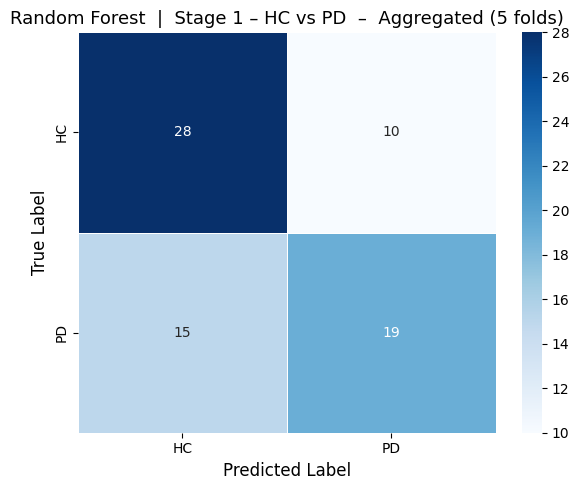

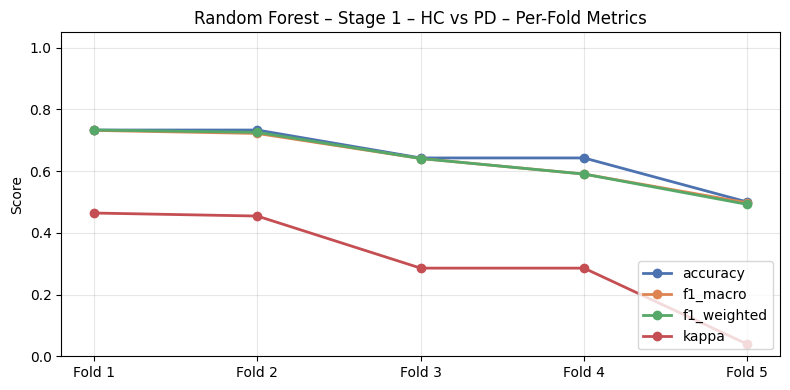

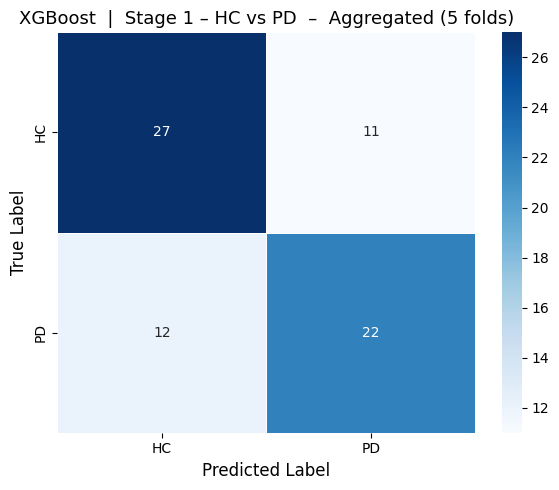

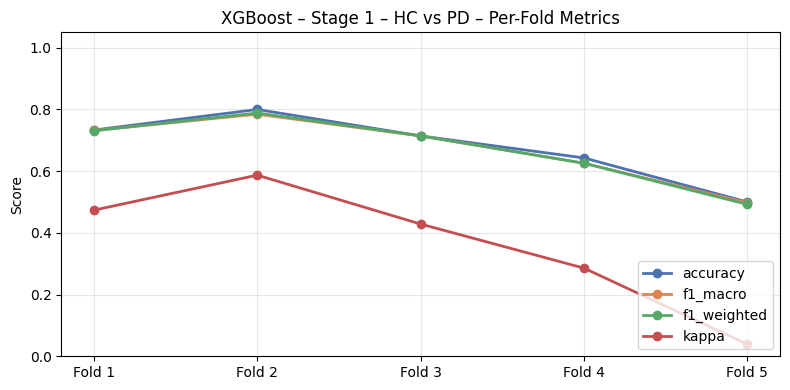


── Stage 2 – Early vs Moderate ──────────────────────────────────────


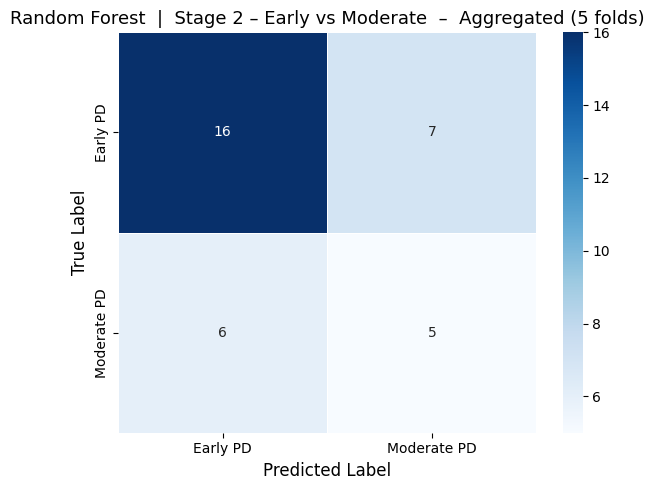

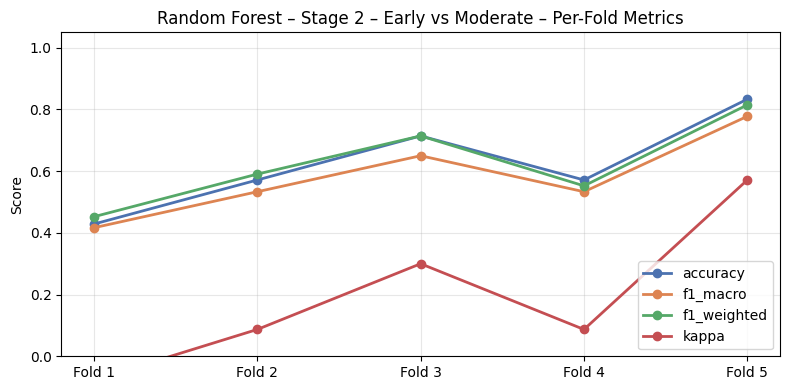

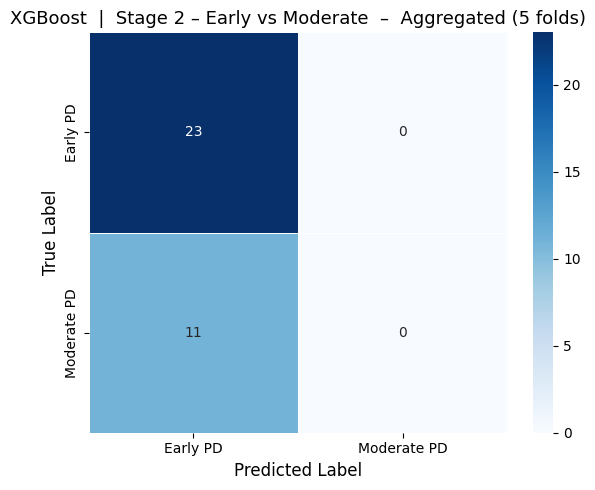

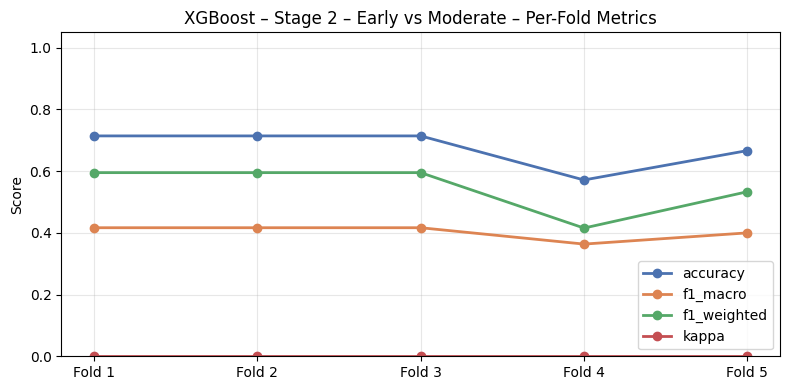


── Feature Importance  |  Stage 1 – HC vs PD ──────────────


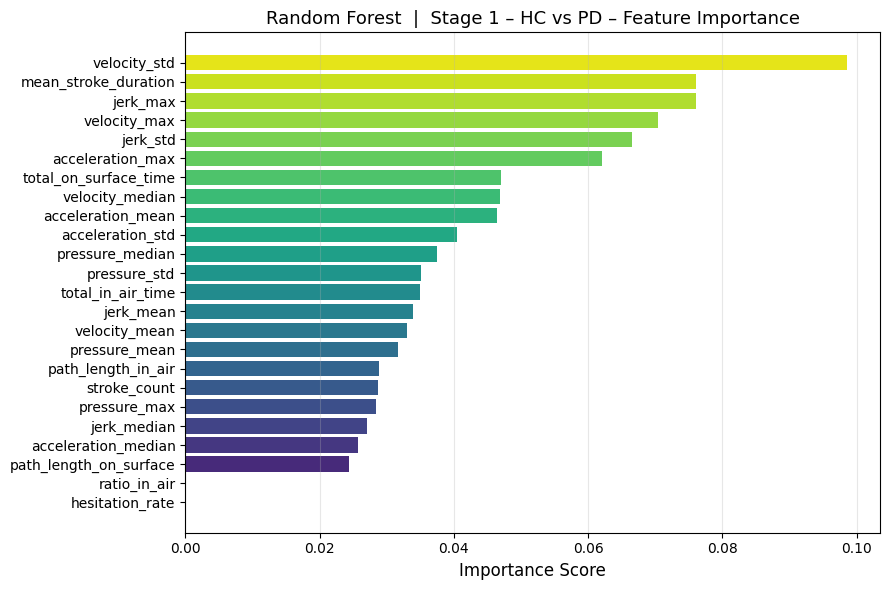


Random Forest  |  Stage 1 – HC vs PD – Top 10 Features:
              Feature  Importance
         velocity_std    0.098566
 mean_stroke_duration    0.076059
             jerk_max    0.076026
         velocity_max    0.070366
             jerk_std    0.066616
     acceleration_max    0.062113
total_on_surface_time    0.047085
      velocity_median    0.046844
    acceleration_mean    0.046488
     acceleration_std    0.040532


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:04:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


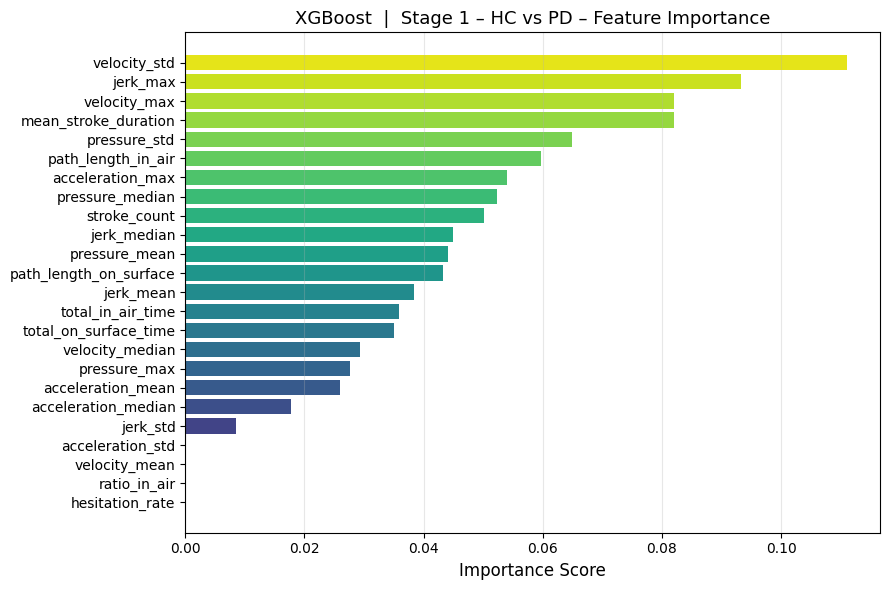


XGBoost  |  Stage 1 – HC vs PD – Top 10 Features:
             Feature  Importance
        velocity_std    0.111055
            jerk_max    0.093225
        velocity_max    0.082001
mean_stroke_duration    0.081997
        pressure_std    0.064834
  path_length_in_air    0.059751
    acceleration_max    0.054071
     pressure_median    0.052266
        stroke_count    0.050147
         jerk_median    0.044886

── Feature Importance  |  Stage 2 – Early vs Moderate ──────────────


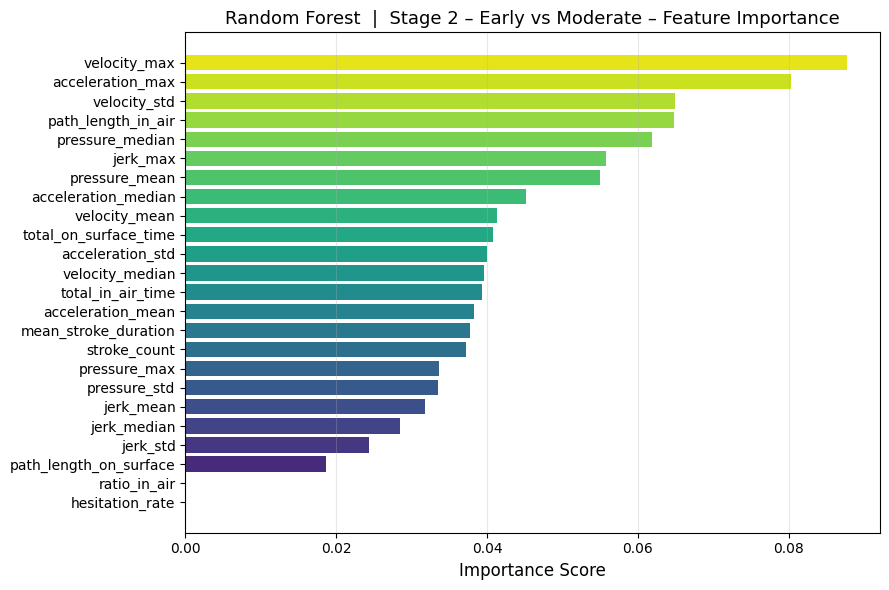


Random Forest  |  Stage 2 – Early vs Moderate – Top 10 Features:
              Feature  Importance
         velocity_max    0.087705
     acceleration_max    0.080243
         velocity_std    0.064902
   path_length_in_air    0.064737
      pressure_median    0.061886
             jerk_max    0.055761
        pressure_mean    0.055003
  acceleration_median    0.045188
        velocity_mean    0.041307
total_on_surface_time    0.040847


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:04:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


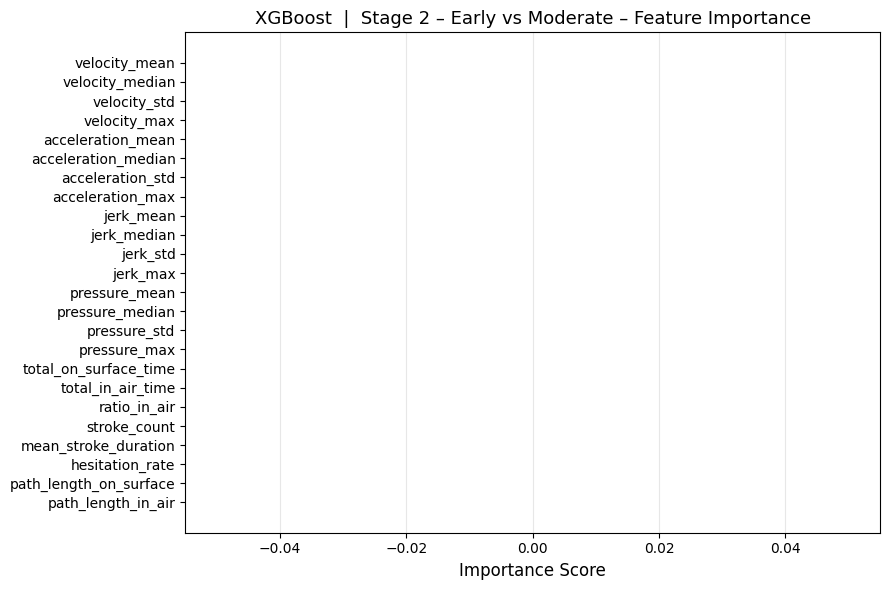


XGBoost  |  Stage 2 – Early vs Moderate – Top 10 Features:
            Feature  Importance
      velocity_mean         0.0
    velocity_median         0.0
       velocity_std         0.0
       velocity_max         0.0
  acceleration_mean         0.0
acceleration_median         0.0
   acceleration_std         0.0
   acceleration_max         0.0
          jerk_mean         0.0
        jerk_median         0.0


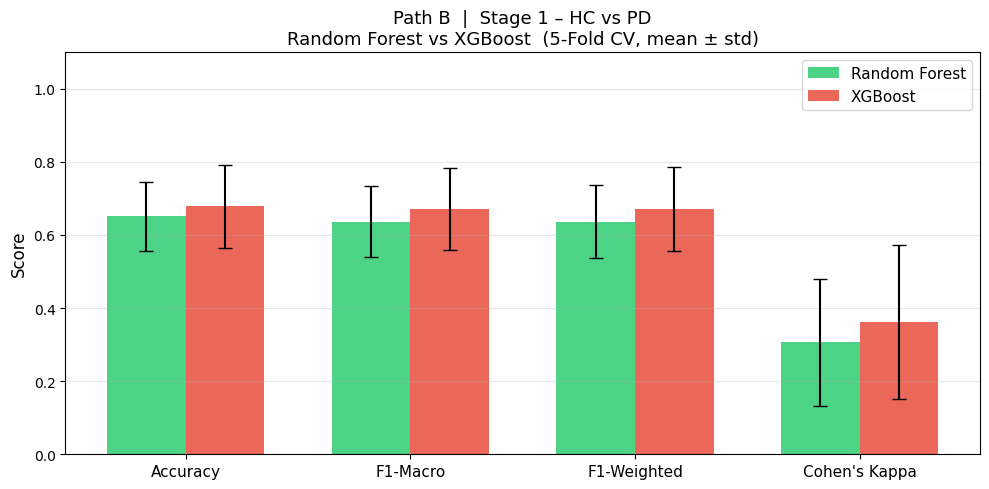

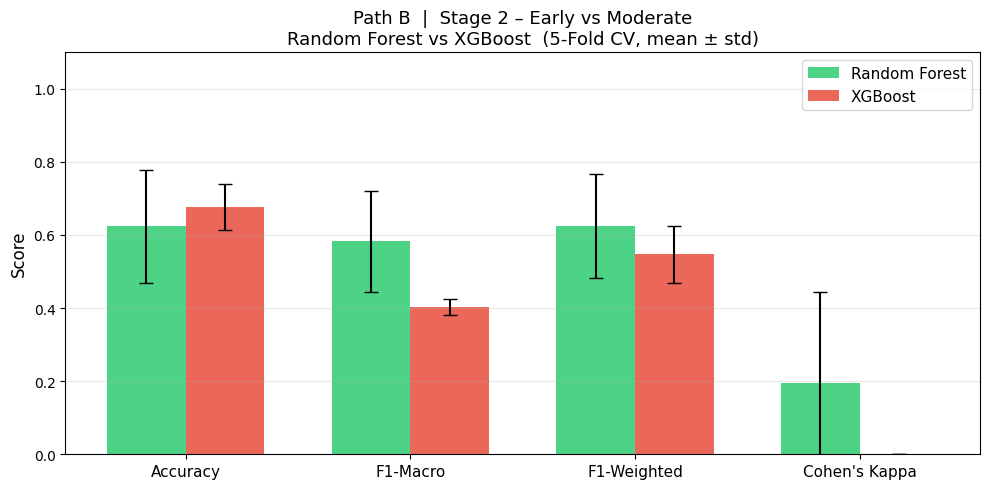


  PATH B  –  FINAL RESULTS SUMMARY

  Stage 1 – HC vs PD:
               accuracy_mean  accuracy_std  f1_macro_mean  f1_macro_std  f1_weighted_mean  f1_weighted_std  kappa_mean  kappa_std
model                                                                                                                            
Random Forest         0.6505        0.0955         0.6367        0.0974            0.6366           0.1004      0.3059     0.1726
XGBoost               0.6781        0.1142         0.6708        0.1126            0.6703           0.1154      0.3629     0.2107

  Stage 2 – Early vs Moderate:
               accuracy_mean  accuracy_std  f1_macro_mean  f1_macro_std  f1_weighted_mean  f1_weighted_std  kappa_mean  kappa_std
model                                                                                                                            
Random Forest         0.6238        0.1547         0.5822         0.137            0.6249           0.1417      0.1937       0.25

In [ ]:
# ============================================================
# PATH B  –  ML
# ============================================================

!pip install xgboost -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble    import RandomForestClassifier
from sklearn.metrics     import (accuracy_score, f1_score,
                                  cohen_kappa_score, confusion_matrix,
                                  classification_report)
from sklearn.base        import clone as sk_clone
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from xgboost             import XGBClassifier

RANDOM_STATE = 42
DEVICE       = 'cpu'

# ============================================================
# LABEL MAPS
# ============================================================
STAGE1_MAP = {
    'Healthy Control' : 0,
    'Early PD'        : 1,
    'Moderate PD'     : 1
}

STAGE2_MAP = {
    'Early PD'    : 0,
    'Moderate PD' : 1
}

CLASS_NAMES_S1 = ['HC', 'PD']
CLASS_NAMES_S2 = ['Early PD', 'Moderate PD']



# ============================================================
# SUBJECT-LEVEL FOLD ASSIGNMENT
# ============================================================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def assign_folds(subj_df: pd.DataFrame) -> pd.DataFrame:
    subj_df        = subj_df.copy()
    subj_df['fold'] = -1
    for fold_idx, (_, val_idx) in enumerate(
            skf.split(subj_df['subject_id'], subj_df['label'])):
        val_subjects = subj_df.iloc[val_idx]['subject_id'].values
        subj_df.loc[subj_df['subject_id'].isin(val_subjects), 'fold'] = fold_idx
    return subj_df

# ── Stage 1: all subjects ─────────────────────────────────
subj_stage1 = (
    feature_df.groupby('subject_id')['group']
    .first()
    .reset_index()
)
subj_stage1.columns = ['subject_id', 'group']
subj_stage1['label'] = subj_stage1['group'].map(STAGE1_MAP)
subj_stage1 = assign_folds(subj_stage1)

# ── Stage 2: PD only ──────────────────────────────────────
subj_stage2 = (
    feature_df[feature_df['group'].isin(['Early PD', 'Moderate PD'])]
    .groupby('subject_id')['group']
    .first()
    .reset_index()
)
subj_stage2.columns = ['subject_id', 'group']
subj_stage2['label'] = subj_stage2['group'].map(STAGE2_MAP)
subj_stage2 = assign_folds(subj_stage2)

# ── Stages config ─────────────────────────────────────────
stages_cfg = [
    ('Stage 1 – HC vs PD',          subj_stage1, STAGE1_MAP, CLASS_NAMES_S1),
    ('Stage 2 – Early vs Moderate', subj_stage2, STAGE2_MAP, CLASS_NAMES_S2),
]

print(f"Stage 1 subjects : {len(subj_stage1)}")
print(f"  HC          : {(subj_stage1['label']==0).sum()}")
print(f"  PD          : {(subj_stage1['label']==1).sum()}")
print(f"\nStage 2 subjects : {len(subj_stage2)}")
print(f"  Early PD    : {(subj_stage2['label']==0).sum()}")
print(f"  Moderate PD : {(subj_stage2['label']==1).sum()}")


# ============================================================
# MODEL DEFINITIONS
# ============================================================

ml_models = {
    'Random Forest': RandomForestClassifier(
        n_estimators      = 200,
        max_depth         = 10,
        min_samples_split = 10,
        min_samples_leaf  = 5,
        max_features      = 'sqrt',
        max_samples       = 0.8,
        class_weight      = 'balanced',
        random_state      = RANDOM_STATE,
        n_jobs            = -1
    ),
    'XGBoost': XGBClassifier(
        n_estimators      = 200,
        max_depth         = 4,
        learning_rate     = 0.05,
        subsample         = 0.7,
        colsample_bytree  = 0.7,
        min_child_weight  = 5,
        gamma             = 0.2,
        reg_alpha         = 0.5,
        reg_lambda        = 2.0,
        objective         = 'binary:logistic',
        eval_metric       = 'logloss',
        use_label_encoder = False,
        random_state      = RANDOM_STATE,
        n_jobs            = -1
    )
}

print("\nModels initialised:")
for name, model in ml_models.items():
    print(f"  ▶  {name}")



# ============================================================
# METRICS & PLOTTING UTILITIES
# ============================================================

def compute_metrics(y_true, y_pred, fold, model_name) -> dict:
    return {
        'model'       : model_name,
        'fold'        : fold,
        'accuracy'    : accuracy_score(y_true, y_pred),
        'f1_macro'    : f1_score(y_true, y_pred,
                                  average='macro',    zero_division=0),
        'f1_weighted' : f1_score(y_true, y_pred,
                                  average='weighted', zero_division=0),
        'kappa'       : cohen_kappa_score(y_true, y_pred),
    }


def summarise_cv(results: list) -> pd.DataFrame:
    df      = pd.DataFrame(results)
    numeric = ['accuracy', 'f1_macro', 'f1_weighted', 'kappa']
    summary = df.groupby('model')[numeric].agg(['mean', 'std'])
    summary.columns = ['_'.join(c) for c in summary.columns]
    return summary.round(4)


def plot_confusion_matrix(cm, model_name, fold, class_names):
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names,
                linewidths=0.5, ax=ax)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label',      fontsize=12)
    ax.set_title(f'{model_name}  –  {fold}', fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_per_fold_metrics(results: list, model_name: str, stage_name: str):
    df    = pd.DataFrame([r for r in results if r['model'] == model_name])
    folds = df['fold'].values + 1

    fig, ax = plt.subplots(figsize=(8, 4))
    for metric, color in zip(
            ['accuracy', 'f1_macro', 'f1_weighted', 'kappa'],
            ['#4C72B0', '#DD8452', '#55A868', '#C44E52']):
        ax.plot(folds, df[metric].values,
                marker='o', linewidth=2, label=metric, color=color)

    ax.set_xticks(folds)
    ax.set_xticklabels([f'Fold {f}' for f in folds])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.set_title(f'{model_name} – {stage_name} – Per-Fold Metrics')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ============================================================
# FOLD BUILDER FOR BOTH STAGES
# ============================================================

def get_path_b_fold_binary(fold_idx:    int,
                            feature_df: pd.DataFrame,
                            subj_df:    pd.DataFrame,
                            label_map:  dict,
                            feat_cols:  list) -> dict:

    valid_groups  = list(label_map.keys())
    stage_df      = feature_df[feature_df['group'].isin(valid_groups)].copy()
    stage_df['label'] = stage_df['group'].map(label_map)

    train_subjs   = set(subj_df[subj_df['fold'] != fold_idx]['subject_id'])
    val_subjs     = set(subj_df[subj_df['fold'] == fold_idx]['subject_id'])

    tr_df         = stage_df[stage_df['subject_id'].isin(train_subjs)]
    val_df        = stage_df[stage_df['subject_id'].isin(val_subjs)]

    X_tr  = tr_df[feat_cols].values.astype(np.float64)
    y_tr  = tr_df['label'].values
    X_val = val_df[feat_cols].values.astype(np.float64)
    y_val = val_df['label'].values

    # Fit scaler on train fold ONLY
    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_tr)
    X_val  = scaler.transform(X_val)

    return {
        'X_train' : X_tr,
        'y_train' : y_tr,
        'X_val'   : X_val,
        'y_val'   : y_val,
        'scaler'  : scaler
    }



# ============================================================
# PATH B  –  5-FOLD CV TRAINING LOOP  (BOTH STAGES)
# ============================================================

path_b_results = {s: [] for s, *_ in stages_cfg}
path_b_cms     = {s: {m: np.zeros((2, 2), dtype=int)
                      for m in ml_models}
                  for s, *_ in stages_cfg}

for stage_name, subj_df, label_map, class_names in stages_cfg:
    print(f"\n{'='*60}")
    print(f"  {stage_name}")
    print(f"{'='*60}")

    for model_name, base_model in ml_models.items():
        print(f"\n  ▶  {model_name}")

        for fold_idx in range(5):
            fold_data = get_path_b_fold_binary(
                fold_idx, feature_df, subj_df, label_map, FEATURE_COLS
            )

            X_tr,  y_tr  = fold_data['X_train'], fold_data['y_train']
            X_val, y_val = fold_data['X_val'],   fold_data['y_val']

            # Fresh model for every fold
            fold_model = (sk_clone(base_model)
                          if model_name == 'Random Forest'
                          else XGBClassifier(**base_model.get_params()))

            fold_model.fit(X_tr, y_tr)
            y_pred = fold_model.predict(X_val)

            metrics = compute_metrics(y_val, y_pred, fold_idx, model_name)
            path_b_results[stage_name].append(metrics)
            path_b_cms[stage_name][model_name] += confusion_matrix(
                y_val, y_pred, labels=[0, 1]
            )

            print(f"    Fold {fold_idx+1}  "
                  f"Acc={metrics['accuracy']:.4f}  "
                  f"F1={metrics['f1_macro']:.4f}  "
                  f"Kappa={metrics['kappa']:.4f}")

        # Classification report on last fold
        print(f"\n  {model_name} – Classification Report (last fold):")
        print(classification_report(y_val, y_pred,
                                     target_names=class_names,
                                     zero_division=0))

    print(f"\n{stage_name} – CV Summary:")
    print(summarise_cv(path_b_results[stage_name]).to_string())



# ============================================================
# CONFUSION MATRICES & PER-FOLD METRIC PLOTS
# ============================================================

for stage_name, subj_df, label_map, class_names in stages_cfg:
    print(f"\n── {stage_name} ──────────────────────────────────────")
    for model_name in ml_models:
        # Aggregated confusion matrix
        plot_confusion_matrix(
            path_b_cms[stage_name][model_name],
            f"{model_name}  |  {stage_name}",
            fold = 'Aggregated (5 folds)',
            class_names = class_names
        )
        # Per-fold metric trend
        plot_per_fold_metrics(
            path_b_results[stage_name],
            model_name,
            stage_name
        )

# ============================================================
# FEATURE IMPORTANCE  (per stage, retrained on full data)
# ============================================================

for stage_name, subj_df, label_map, class_names in stages_cfg:
    print(f"\n── Feature Importance  |  {stage_name} ──────────────")

    valid_groups  = list(label_map.keys())
    stage_df      = feature_df[feature_df['group'].isin(valid_groups)].copy()
    stage_df['label'] = stage_df['group'].map(label_map)

    X_full = stage_df[FEATURE_COLS].values.astype(np.float64)
    y_full = stage_df['label'].values

    scaler_full   = StandardScaler()
    X_full_scaled = scaler_full.fit_transform(X_full)

    for model_name, base_model in ml_models.items():
        insp_model = (sk_clone(base_model)
                      if model_name == 'Random Forest'
                      else XGBClassifier(**base_model.get_params()))

        insp_model.fit(X_full_scaled, y_full)

        imp_df = (
            pd.DataFrame({'Feature'   : FEATURE_COLS,
                          'Importance': insp_model.feature_importances_})
            .sort_values('Importance', ascending=False)
            .reset_index(drop=True)
        )

        fig, ax = plt.subplots(figsize=(9, 6))
        colors  = sns.color_palette('viridis', len(FEATURE_COLS))
        ax.barh(imp_df['Feature'][::-1],
                imp_df['Importance'][::-1],
                color=colors)
        ax.set_xlabel('Importance Score', fontsize=12)
        ax.set_title(f'{model_name}  |  {stage_name} – Feature Importance',
                     fontsize=13)
        ax.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()

        print(f"\n{model_name}  |  {stage_name} – Top 10 Features:")
        print(imp_df.head(10).to_string(index=False))


# ============================================================
# FINAL COMPARISON CHART  –  RF vs XGBoost  per stage
# ============================================================

metrics_to_plot = ['accuracy_mean', 'f1_macro_mean',
                   'f1_weighted_mean', 'kappa_mean']
error_cols      = ['accuracy_std',  'f1_macro_std',
                   'f1_weighted_std', 'kappa_std']
x_labels        = ['Accuracy', 'F1-Macro', 'F1-Weighted', "Cohen's Kappa"]

for stage_name, *_ in stages_cfg:
    summary_b = summarise_cv(path_b_results[stage_name])

    x      = np.arange(len(metrics_to_plot))
    width  = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    colors  = ['#2ecc71', '#e74c3c']

    for i, (model_name, color) in enumerate(zip(summary_b.index, colors)):
        means = summary_b.loc[model_name, metrics_to_plot].values.astype(float)
        stds  = summary_b.loc[model_name, error_cols].values.astype(float)
        ax.bar(x + i * width, means, width,
               yerr=stds, label=model_name,
               color=color, capsize=5, alpha=0.85)

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(x_labels, fontsize=11)
    ax.set_ylim(0, 1.10)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title(f'Path B  |  {stage_name}\n'
                 f'Random Forest vs XGBoost  (5-Fold CV, mean ± std)',
                 fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# ── Print final summary for all stages ───────────────────
print("\n" + "="*60)
print("  PATH B  –  FINAL RESULTS SUMMARY")
print("="*60)
for stage_name, *_ in stages_cfg:
    print(f"\n  {stage_name}:")
    print(summarise_cv(path_b_results[stage_name]).to_string())

  SECTION 1 – CV RESULTS SUMMARY

  Stage 1 – HC vs PD
  --------------------------------------------------

  Random Forest
  Fold       Accuracy   F1-Macro  F1-Weight      Kappa
  --------------------------------------------------
  Fold 1        0.7333     0.7321     0.7333     0.4643
  Fold 2        0.7333     0.7222     0.7259     0.4545
  Fold 3        0.6429     0.6410     0.6410     0.2857
  Fold 4        0.6429     0.5906     0.5906     0.2857
  Fold 5        0.5000     0.4974     0.4923     0.0392
  --------------------------------------------------
  Mean          0.6505     0.6367     0.6366     0.3059
  Std           0.0955     0.0974     0.1004     0.1726

  XGBoost
  Fold       Accuracy   F1-Macro  F1-Weight      Kappa
  --------------------------------------------------
  Fold 1        0.7333     0.7321     0.7310     0.4737
  Fold 2        0.8000     0.7847     0.7885     0.5872
  Fold 3        0.7143     0.7143     0.7143     0.4286
  Fold 4        0.6429     0.6257  

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:04:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  XGBoost            1          0.7368     0.7333     0.0035         ✅  GOOD


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:04:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  XGBoost            2          0.7719     0.8000    -0.0281         ✅  GOOD


...

  XGBoost            2          0.6667     0.7143    -0.0476         ✅  GOOD


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:04:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  XGBoost            3          0.6667     0.7143    -0.0476         ✅  GOOD
  XGBoost            4          0.7037     0.5714     0.1323  ⚠️  SLIGHT OVF


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:04:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:04:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  XGBoost            5          0.6786     0.6667     0.0119         ✅  GOOD

  SECTION 3 – TRAIN vs VAL ACCURACY PLOTS


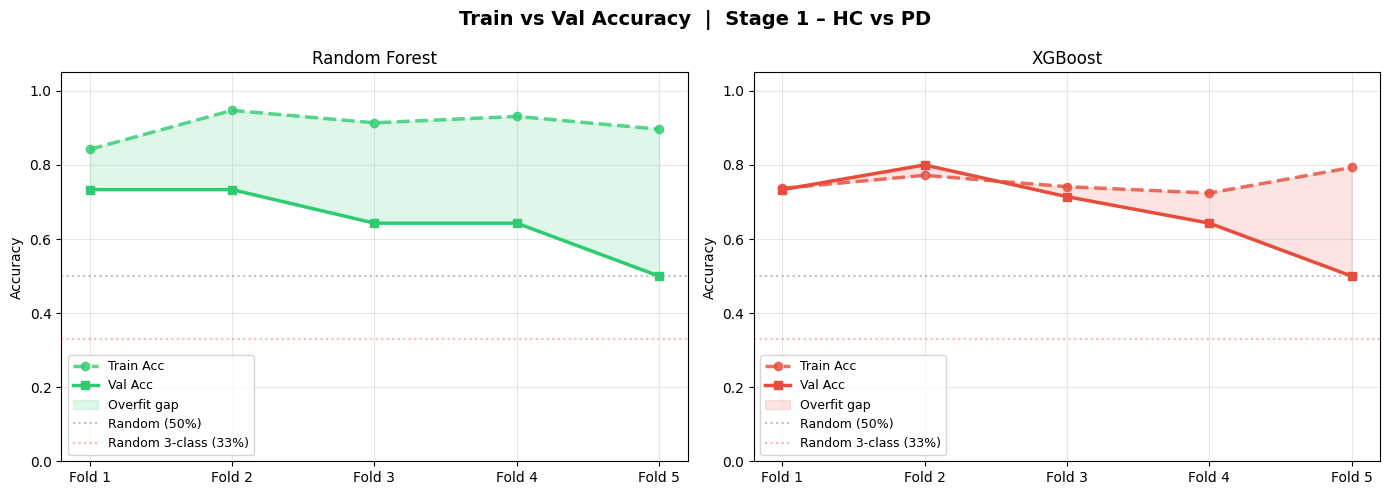

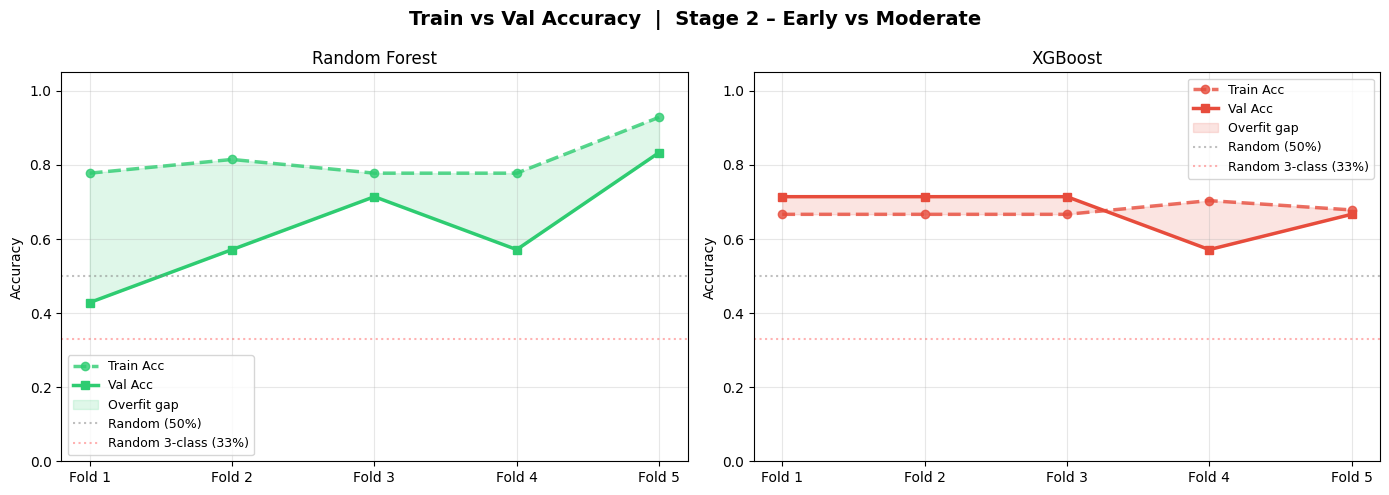


  SECTION 4 – METRIC STABILITY (std across folds)
  Rule of thumb:  std > 0.10 = unstable,  std < 0.05 = stable


  Stage 1 – HC vs PD

  Random Forest
    accuracy         mean=0.6505   std=0.0955  ⚠️ 
    f1_macro         mean=0.6367   std=0.0974  ⚠️ 
    f1_weighted      mean=0.6366   std=0.1004  ❌
    kappa            mean=0.3059   std=0.1726  ❌

  XGBoost
    accuracy         mean=0.6781   std=0.1142  ❌
    f1_macro         mean=0.6708   std=0.1126  ❌
    f1_weighted      mean=0.6703   std=0.1154  ❌
    kappa            mean=0.3629   std=0.2107  ❌

  Stage 2 – Early vs Moderate

  Random Forest
    accuracy         mean=0.6238   std=0.1547  ❌
    f1_macro         mean=0.5822   std=0.1370  ❌
    f1_weighted      mean=0.6249   std=0.1417  ❌
    kappa            mean=0.1937   std=0.2500  ❌

  XGBoost
    accuracy         mean=0.6762   std=0.0621  ⚠️ 
    f1_macro         mean=0.4027   std=0.0230  ✅
    f1_weighted      mean=0.5469   std=0.0782  ⚠️ 
    kappa            mean=0.0000  

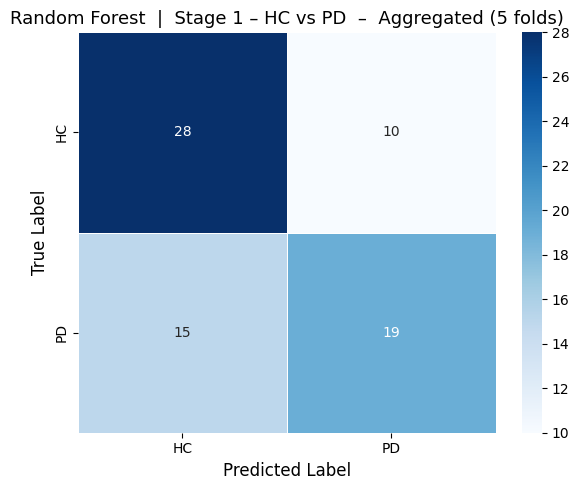


  Random Forest – CM Analysis:
    HC               TP= 28  FN= 10  Recall=0.7368  ✅  OK
    PD               TP= 19  FN= 15  Recall=0.5588  ⚠️   LOW RECALL

    Prediction distribution:
      Predicted HC             :  43 / 72  (59.7%)
      Predicted PD             :  29 / 72  (40.3%)


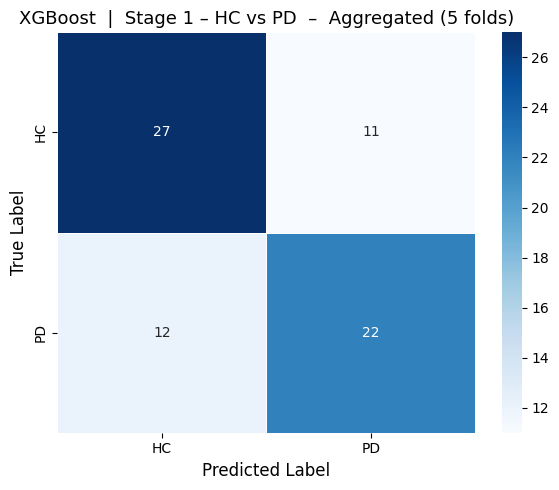


  XGBoost – CM Analysis:
    HC               TP= 27  FN= 11  Recall=0.7105  ✅  OK
    PD               TP= 22  FN= 12  Recall=0.6471  ✅  OK

    Prediction distribution:
      Predicted HC             :  39 / 72  (54.2%)
      Predicted PD             :  33 / 72  (45.8%)

  Stage 2 – Early vs Moderate


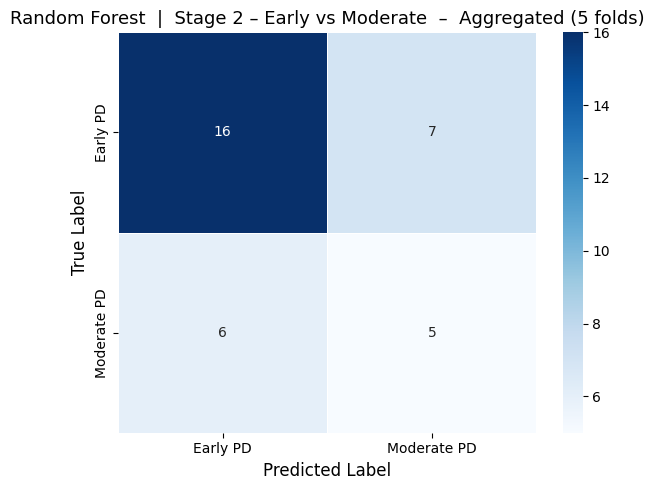


  Random Forest – CM Analysis:
    Early PD         TP= 16  FN=  7  Recall=0.6957  ✅  OK
    Moderate PD      TP=  5  FN=  6  Recall=0.4545  ⚠️   LOW RECALL

    Prediction distribution:
      Predicted Early PD       :  22 / 34  (64.7%)
      Predicted Moderate PD    :  12 / 34  (35.3%)


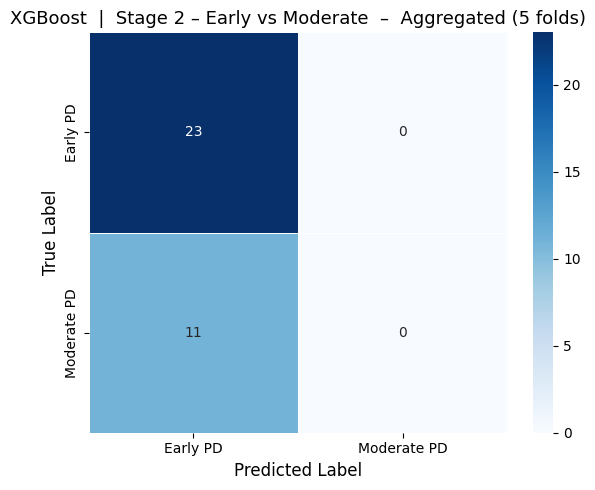


  XGBoost – CM Analysis:
    Early PD         TP= 23  FN=  0  Recall=1.0000  ✅  OK
    Moderate PD      TP=  0  FN= 11  Recall=0.0000  ❌  POOR RECALL

    Prediction distribution:
      Predicted Early PD       :  34 / 34  (100.0%)
      ❌  Model almost always predicts Early PD → class collapse!
      Predicted Moderate PD    :   0 / 34  (0.0%)
      ❌  Model almost never predicts Moderate PD  → class collapse!

  SECTION 6 – FULL CLASSIFICATION REPORTS

  Stage 1 – HC vs PD

  Random Forest
  Aggregated across all 5 folds:
              precision    recall  f1-score   support

          HC       0.65      0.74      0.69        38
          PD       0.66      0.56      0.60        34

    accuracy                           0.65        72
   macro avg       0.65      0.65      0.65        72
weighted avg       0.65      0.65      0.65        72


  XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:05:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:05:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:05:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:05:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

  Aggregated across all 5 folds:
              precision    recall  f1-score   support

          HC       0.69      0.71      0.70        38
          PD       0.67      0.65      0.66        34

    accuracy                           0.68        72
   macro avg       0.68      0.68      0.68        72
weighted avg       0.68      0.68      0.68        72


  Stage 2 – Early vs Moderate

  Random Forest
  Aggregated across all 5 folds:
              precision    recall  f1-score   support

    Early PD       0.73      0.70      0.71        23
 Moderate PD       0.42      0.45      0.43        11

    accuracy                           0.62        34
   macro avg       0.57      0.58      0.57        34
weighted avg       0.63      0.62      0.62        34


  XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:05:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:05:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:05:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:05:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

  Aggregated across all 5 folds:
              precision    recall  f1-score   support

    Early PD       0.68      1.00      0.81        23
 Moderate PD       0.00      0.00      0.00        11

    accuracy                           0.68        34
   macro avg       0.34      0.50      0.40        34
weighted avg       0.46      0.68      0.55        34


  SECTION 7 – MODEL HEALTH SUMMARY

  Stage 1 – HC vs PD

  ▶  Random Forest
     Accuracy  : 0.6505  ⚠️   MODERATE
     Stability : std=0.0955  ⚠️   MODERATE
     Overfit   : gap=0.2557  ❌  OVERFITTING
     Kappa     : 0.3059  ⚠️   FAIR AGREEMENT

  ▶  XGBoost
     Accuracy  : 0.6781  ⚠️   MODERATE
     Stability : std=0.1142  ❌  UNSTABLE
     Overfit   : gap=0.0754  ✅  NO OVERFIT
     Kappa     : 0.3629  ⚠️   FAIR AGREEMENT

  Stage 2 – Early vs Moderate

  ▶  Random Forest
     Accuracy  : 0.6238  ⚠️   MODERATE
     Stability : std=0.1547  ❌  UNSTABLE
     Overfit   : gap=0.1915  ❌  OVERFITTING
     Kappa     : 0.1937  ❌  POOR A

In [ ]:
# ============================================================
# COMPREHENSIVE RESULTS DIAGNOSTIC
# PATH B  –  Random Forest & XGBoost
# Both Stages
# ============================================================

# ============================================================
# 1. CV RESULTS TABLE  –  mean ± std per model per stage
# ============================================================

print("=" * 70)
print("  SECTION 1 – CV RESULTS SUMMARY")
print("=" * 70)

for stage_name, *_ in stages_cfg:
    print(f"\n  {stage_name}")
    print("  " + "-" * 50)
    df = pd.DataFrame(path_b_results[stage_name])

    for model_name in ml_models:
        model_df = df[df['model'] == model_name]
        print(f"\n  {model_name}")
        print(f"  {'Fold':<8} {'Accuracy':>10} {'F1-Macro':>10} "
              f"{'F1-Weight':>10} {'Kappa':>10}")
        print(f"  {'-'*50}")
        for _, row in model_df.iterrows():
            print(f"  Fold {int(row['fold'])+1:<3}  "
                  f"{row['accuracy']:>10.4f} "
                  f"{row['f1_macro']:>10.4f} "
                  f"{row['f1_weighted']:>10.4f} "
                  f"{row['kappa']:>10.4f}")
        print(f"  {'-'*50}")
        print(f"  {'Mean':<8}  "
              f"{model_df['accuracy'].mean():>10.4f} "
              f"{model_df['f1_macro'].mean():>10.4f} "
              f"{model_df['f1_weighted'].mean():>10.4f} "
              f"{model_df['kappa'].mean():>10.4f}")
        print(f"  {'Std':<8}  "
              f"{model_df['accuracy'].std():>10.4f} "
              f"{model_df['f1_macro'].std():>10.4f} "
              f"{model_df['f1_weighted'].std():>10.4f} "
              f"{model_df['kappa'].std():>10.4f}")

# ============================================================
# 2. OVERFITTING CHECK
#    Compare train vs val accuracy on each fold
# ============================================================

print("\n" + "=" * 70)
print("  SECTION 2 – OVERFITTING CHECK (Train vs Val Accuracy)")
print("=" * 70)

overfit_records = []

for stage_name, subj_df, label_map, class_names in stages_cfg:
    print(f"\n  {stage_name}")
    print(f"  {'Model':<18} {'Fold':<6} {'Train Acc':>10} "
          f"{'Val Acc':>10} {'Gap':>10} {'Status':>15}")
    print("  " + "-" * 65)

    for model_name, base_model in ml_models.items():
        for fold_idx in range(5):
            fold_data = get_path_b_fold_binary(
                fold_idx, feature_df, subj_df, label_map, FEATURE_COLS
            )
            X_tr,  y_tr  = fold_data['X_train'], fold_data['y_train']
            X_val, y_val = fold_data['X_val'],   fold_data['y_val']

            fold_model = (sk_clone(base_model)
                          if model_name == 'Random Forest'
                          else XGBClassifier(**base_model.get_params()))

            fold_model.fit(X_tr, y_tr)

            train_acc = accuracy_score(y_tr,  fold_model.predict(X_tr))
            val_acc   = accuracy_score(y_val, fold_model.predict(X_val))
            gap       = train_acc - val_acc

            # Diagnose
            if gap > 0.15:
                status = '⚠️  OVERFIT'
            elif val_acc < 0.55:
                status = '⚠️  UNDERFIT'
            elif gap < 0.05:
                status = '✅  GOOD'
            else:
                status = '⚠️  SLIGHT OVF'

            print(f"  {model_name:<18} {fold_idx+1:<6} "
                  f"{train_acc:>10.4f} {val_acc:>10.4f} "
                  f"{gap:>10.4f} {status:>15}")

            overfit_records.append({
                'stage'     : stage_name,
                'model'     : model_name,
                'fold'      : fold_idx + 1,
                'train_acc' : train_acc,
                'val_acc'   : val_acc,
                'gap'       : gap
            })


# ============================================================
# 3. TRAIN VS VAL ACCURACY  –  visual per stage per model
# ============================================================

print("\n" + "=" * 70)
print("  SECTION 3 – TRAIN vs VAL ACCURACY PLOTS")
print("=" * 70)

overfit_df = pd.DataFrame(overfit_records)
folds      = [1, 2, 3, 4, 5]
colors     = {'Random Forest': '#2ecc71', 'XGBoost': '#e74c3c'}

for stage_name, *_ in stages_cfg:
    stage_df = overfit_df[overfit_df['stage'] == stage_name]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Train vs Val Accuracy  |  {stage_name}',
                 fontsize=14, fontweight='bold')

    for ax, model_name in zip(axes, ml_models):
        mdf = stage_df[stage_df['model'] == model_name]
        color = colors[model_name]

        ax.plot(folds, mdf['train_acc'].values,
                marker='o', linewidth=2.5, linestyle='--',
                color=color, label='Train Acc', alpha=0.8)
        ax.plot(folds, mdf['val_acc'].values,
                marker='s', linewidth=2.5, linestyle='-',
                color=color, label='Val Acc')

        # Shade the gap
        ax.fill_between(folds,
                         mdf['train_acc'].values,
                         mdf['val_acc'].values,
                         alpha=0.15, color=color,
                         label='Overfit gap')

        # Reference lines
        ax.axhline(0.5,  color='gray', linestyle=':', alpha=0.5,
                   label='Random (50%)')
        ax.axhline(0.33, color='red',  linestyle=':', alpha=0.3,
                   label='Random 3-class (33%)')

        ax.set_xticks(folds)
        ax.set_xticklabels([f'Fold {f}' for f in folds])
        ax.set_ylim(0, 1.05)
        ax.set_ylabel('Accuracy')
        ax.set_title(f'{model_name}')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ============================================================
# 4. METRIC STABILITY CHECK
#    High std across folds = unstable / unreliable model
# ============================================================

print("\n" + "=" * 70)
print("  SECTION 4 – METRIC STABILITY (std across folds)")
print("=" * 70)
print("  Rule of thumb:  std > 0.10 = unstable,  std < 0.05 = stable")
print()

for stage_name, *_ in stages_cfg:
    print(f"\n  {stage_name}")
    summary = summarise_cv(path_b_results[stage_name])

    for model_name in ml_models:
        row = summary.loc[model_name]
        print(f"\n  {model_name}")
        for metric in ['accuracy', 'f1_macro', 'f1_weighted', 'kappa']:
            mean = row[f'{metric}_mean']
            std  = row[f'{metric}_std']
            flag = '✅' if std < 0.05 else ('⚠️ ' if std < 0.10 else '❌')
            print(f"    {metric:<15}  mean={mean:.4f}   std={std:.4f}  {flag}")


# ============================================================
# 5. CONFUSION MATRIX ANALYSIS
#    Check for class bias (model always predicting one class)
# ============================================================

print("\n" + "=" * 70)
print("  SECTION 5 – CONFUSION MATRIX ANALYSIS")
print("=" * 70)

for stage_name, subj_df, label_map, class_names in stages_cfg:
    print(f"\n  {stage_name}")

    for model_name in ml_models:
        cm = path_b_cms[stage_name][model_name]

        # Plot
        plot_confusion_matrix(
            cm,
            f"{model_name}  |  {stage_name}",
            fold='Aggregated (5 folds)',
            class_names=class_names
        )

        # Analyse
        total      = cm.sum()
        row_totals = cm.sum(axis=1)

        print(f"\n  {model_name} – CM Analysis:")
        for i, cls in enumerate(class_names):
            tp = cm[i, i]
            fn = row_totals[i] - tp
            recall = tp / row_totals[i] if row_totals[i] > 0 else 0
            print(f"    {cls:<15}  "
                  f"TP={tp:>3}  FN={fn:>3}  "
                  f"Recall={recall:.4f}  ", end='')
            if recall < 0.40:
                print("❌  POOR RECALL")
            elif recall < 0.60:
                print("⚠️   LOW RECALL")
            else:
                print("✅  OK")

        # Check for class collapse (model predicts only one class)
        col_totals = cm.sum(axis=0)
        print(f"\n    Prediction distribution:")
        for i, cls in enumerate(class_names):
            pct = col_totals[i] / total * 100
            print(f"      Predicted {cls:<15}: "
                  f"{col_totals[i]:>3} / {total}  ({pct:.1f}%)")
            if pct < 5:
                print(f"      ❌  Model almost never predicts {cls}  → class collapse!")
            elif pct > 95:
                print(f"      ❌  Model almost always predicts {cls} → class collapse!")


# ============================================================
# 6. CLASSIFICATION REPORT  –  all folds, all models
# ============================================================

print("\n" + "=" * 70)
print("  SECTION 6 – FULL CLASSIFICATION REPORTS")
print("=" * 70)

for stage_name, subj_df, label_map, class_names in stages_cfg:
    print(f"\n  {stage_name}")

    for model_name, base_model in ml_models.items():
        print(f"\n  {model_name}")

        all_y_true = []
        all_y_pred = []

        for fold_idx in range(5):
            fold_data = get_path_b_fold_binary(
                fold_idx, feature_df, subj_df, label_map, FEATURE_COLS
            )
            X_tr,  y_tr  = fold_data['X_train'], fold_data['y_train']
            X_val, y_val = fold_data['X_val'],   fold_data['y_val']

            fold_model = (sk_clone(base_model)
                          if model_name == 'Random Forest'
                          else XGBClassifier(**base_model.get_params()))

            fold_model.fit(X_tr, y_tr)
            y_pred = fold_model.predict(X_val)

            all_y_true.extend(y_val)
            all_y_pred.extend(y_pred)

        print(f"  Aggregated across all 5 folds:")
        print(classification_report(
            all_y_true, all_y_pred,
            target_names=class_names,
            zero_division=0
        ))


# ============================================================
# 7. FINAL HEALTH SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("  SECTION 7 – MODEL HEALTH SUMMARY")
print("=" * 70)

for stage_name, *_ in stages_cfg:
    print(f"\n  {stage_name}")
    summary = summarise_cv(path_b_results[stage_name])
    stage_overfit = overfit_df[overfit_df['stage'] == stage_name]

    for model_name in ml_models:
        row      = summary.loc[model_name]
        mean_acc = row['accuracy_mean']
        std_acc  = row['accuracy_std']
        mean_gap = stage_overfit[
            stage_overfit['model'] == model_name]['gap'].mean()

        print(f"\n  ▶  {model_name}")

        # Accuracy check
        if mean_acc >= 0.75:
            print(f"     Accuracy  : {mean_acc:.4f}  ✅  GOOD")
        elif mean_acc >= 0.60:
            print(f"     Accuracy  : {mean_acc:.4f}  ⚠️   MODERATE")
        else:
            print(f"     Accuracy  : {mean_acc:.4f}  ❌  POOR")

        # Stability check
        if std_acc < 0.05:
            print(f"     Stability : std={std_acc:.4f}  ✅  STABLE")
        elif std_acc < 0.10:
            print(f"     Stability : std={std_acc:.4f}  ⚠️   MODERATE")
        else:
            print(f"     Stability : std={std_acc:.4f}  ❌  UNSTABLE")

        # Overfitting check
        if mean_gap > 0.15:
            print(f"     Overfit   : gap={mean_gap:.4f}  ❌  OVERFITTING")
        elif mean_gap > 0.08:
            print(f"     Overfit   : gap={mean_gap:.4f}  ⚠️   SLIGHT OVERFIT")
        else:
            print(f"     Overfit   : gap={mean_gap:.4f}  ✅  NO OVERFIT")

        # Kappa check
        kappa = row['kappa_mean']
        if kappa >= 0.61:
            print(f"     Kappa     : {kappa:.4f}  ✅  SUBSTANTIAL AGREEMENT")
        elif kappa >= 0.41:
            print(f"     Kappa     : {kappa:.4f}  ⚠️   MODERATE AGREEMENT")
        elif kappa >= 0.21:
            print(f"     Kappa     : {kappa:.4f}  ⚠️   FAIR AGREEMENT")
        else:
            print(f"     Kappa     : {kappa:.4f}  ❌  POOR AGREEMENT")

In [ ]:
# ============================================================
# PATH A  –  DEEP LEARNING MODELS  (LSTM & GRU)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

from sklearn.ensemble    import RandomForestClassifier
from sklearn.metrics     import (accuracy_score, f1_score,
                                  cohen_kappa_score, confusion_matrix,
                                  classification_report)
from sklearn.base        import clone as sk_clone
from sklearn.preprocessing import StandardScaler
from xgboost             import XGBClassifier

RANDOM_STATE = 42
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASS_NAMES_S1 = ['HC', 'PD']
CLASS_NAMES_S2 = ['Early PD', 'Moderate PD']

print(f"Device : {DEVICE}")

# ============================================================
# LABEL MAPS
# ============================================================

# Stage 1: HC=0, PD=1
STAGE1_MAP = {
    'Healthy Control' : 0,
    'Early PD'        : 1,
    'Moderate PD'     : 1
}

# Stage 2: Early=0, Moderate=1  (PD subjects only)
STAGE2_MAP = {
    'Early PD'    : 0,
    'Moderate PD' : 1
}

# ============================================================
# SUBJECT-LEVEL FOLD ASSIGNMENT  –  one per stage
# ============================================================

# ── Stage 1 subjects (all 75) ─────────────────────────────
subj_stage1 = (
    feature_df.groupby('subject_id')['group']
    .first()
    .reset_index()
)
subj_stage1['label'] = subj_stage1['group'].map(STAGE1_MAP)

# ── Stage 2 subjects (PD only) ────────────────────────────
subj_stage2 = (
    feature_df[feature_df['group'].isin(['Early PD', 'Moderate PD'])]
    .groupby('subject_id')['group']
    .first()
    .reset_index()
)
subj_stage2['label'] = subj_stage2['group'].map(STAGE2_MAP)

print(f"Stage 1  –  Total subjects : {len(subj_stage1)}")
print(f"  HC          : {(subj_stage1['label']==0).sum()}")
print(f"  PD          : {(subj_stage1['label']==1).sum()}")

print(f"\nStage 2  –  Total subjects : {len(subj_stage2)}")
print(f"  Early PD    : {(subj_stage2['label']==0).sum()}")
print(f"  Moderate PD : {(subj_stage2['label']==1).sum()}")

# ============================================================
# BUILD STRATIFIED 5-FOLD SPLITS  –  subject level
# ============================================================
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def assign_folds(subj_df: pd.DataFrame) -> pd.DataFrame:
    subj_df = subj_df.copy()
    subj_df['fold'] = -1
    for fold_idx, (_, val_idx) in enumerate(
            skf.split(subj_df['subject_id'], subj_df['label'])):
        val_subjects = subj_df.iloc[val_idx]['subject_id'].values
        subj_df.loc[subj_df['subject_id'].isin(val_subjects), 'fold'] = fold_idx
    return subj_df

subj_stage1 = assign_folds(subj_stage1)
subj_stage2 = assign_folds(subj_stage2)

# ── Verify fold distributions ─────────────────────────────
for stage_name, subj_df, class_names in [
        ('Stage 1', subj_stage1, ['HC', 'PD']),
        ('Stage 2', subj_stage2, ['Early', 'Moderate'])]:
    print(f"\n{stage_name} fold distribution:")
    print(f"  {'Fold':<6} {'Total':>6} {class_names[0]:>8} {class_names[1]:>10}")
    for f in range(5):
        fd = subj_df[subj_df['fold'] == f]
        print(f"  {f:<6} {len(fd):>6} "
              f"{(fd['label']==0).sum():>8} "
              f"{(fd['label']==1).sum():>10}")

# ============================================================
# MODEL DEFINITIONS
# ============================================================

class LSTMClassifier(nn.Module):
    def __init__(self,
                 input_size  = 4,
                 hidden_size = 64,    # REDUCED from 128
                 num_layers  = 1,     # REDUCED from 2 (less depth)
                 num_classes = 2,     # BINARY
                 dropout     = 0.5):  # INCREASED from 0.3
        super().__init__()

        self.lstm = nn.LSTM(
            input_size    = input_size,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            dropout       = 0.0,       # no inter-layer dropout (1 layer)
            bidirectional = False
        )
        self.batch_norm = nn.BatchNorm1d(hidden_size * 2)  # ADDED
        self.dropout    = nn.Dropout(dropout)
        self.fc         = nn.Sequential(
            nn.Linear(hidden_size * 2, 32),  # REDUCED from 64
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        out, _  = self.lstm(x)
        out     = out[:, -1, :]
        out     = self.batch_norm(out)   # normalise before FC
        out     = self.dropout(out)
        return self.fc(out)


class GRUClassifier(nn.Module):
    def __init__(self,
                 input_size  = 4,
                 hidden_size = 64,    # REDUCED from 128
                 num_layers  = 1,     # REDUCED from 2
                 num_classes = 2,
                 dropout     = 0.5):  # INCREASED from 0.3
        super().__init__()

        self.gru = nn.GRU(
            input_size    = input_size,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            dropout       = 0.0,
            bidirectional = False
        )
        self.batch_norm = nn.BatchNorm1d(hidden_size * 2)  # ADDED
        self.dropout    = nn.Dropout(dropout)
        self.fc         = nn.Sequential(
            nn.Linear(hidden_size * 2, 32),  # REDUCED from 64
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        out, _  = self.gru(x)
        out     = out[:, -1, :]
        out     = self.batch_norm(out)
        out     = self.dropout(out)
        return self.fc(out)

# ============================================================
# TRAINING UTILITIES
# ============================================================

def make_dataloader(X: np.ndarray,
                    y: np.ndarray,
                    batch_size: int,
                    shuffle:    bool) -> DataLoader:
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(X_t, y_t),
                      batch_size=batch_size,
                      shuffle=shuffle)


def train_one_epoch(model, loader, optimizer, criterion) -> tuple:
    model.train()
    total_loss, correct, n = 0.0, 0, 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
        n          += len(y_batch)

    return total_loss / n, correct / n


@torch.no_grad()
def evaluate_loader(model, loader) -> tuple:
    model.eval()
    preds, trues, total_loss, n = [], [], 0.0, 0
    criterion = nn.CrossEntropyLoss()

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        logits   = model(X_batch)
        loss     = criterion(logits, y_batch)

        total_loss += loss.item() * len(y_batch)
        preds.extend(logits.argmax(1).cpu().numpy())
        trues.extend(y_batch.cpu().numpy())
        n += len(y_batch)

    return np.array(trues), np.array(preds), total_loss / n


# ============================================================
# UPDATED TRAINING FUNCTION  –  stronger regularisation
# ============================================================

def train_dl_binary(model_class,
                   fold_data:   dict,
                   epochs:      int   = 100,   # MORE epochs, rely on early stop
                   batch_size:  int   = 16,    # SMALLER batch (more updates, better generalisation)
                   lr:          float = 1e-3,  # LOWER lr
                   patience:    int   = 20,    # MORE patience before stopping
                   weight_decay:float = 1e-3): # STRONGER L2 regularisation

    X_tr,  y_tr  = fold_data['X_train'], fold_data['y_train']
    X_val, y_val = fold_data['X_val'],   fold_data['y_val']

    # Weighted sampler for class balance
    class_counts   = np.bincount(y_tr)
    sample_weights = torch.tensor(
        [1.0 / class_counts[y] for y in y_tr], dtype=torch.float32
    )
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights),
                                    replacement=True)

    X_t = torch.tensor(X_tr,  dtype=torch.float32)
    y_t = torch.tensor(y_tr,  dtype=torch.long)
    X_v = torch.tensor(X_val, dtype=torch.float32)
    y_v = torch.tensor(y_val, dtype=torch.long)

    train_loader = DataLoader(TensorDataset(X_t, y_t),
                              batch_size=batch_size, sampler=sampler)
    val_loader   = DataLoader(TensorDataset(X_v, y_v),
                              batch_size=batch_size, shuffle=False)

    model     = model_class(num_classes=2).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr,
                           weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=epochs, eta_min=1e-6)

    history        = {'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[]}
    best_val_loss  = np.inf
    patience_count = 0
    best_weights   = None

    for epoch in range(epochs):
        tr_loss, tr_acc       = train_one_epoch(model, train_loader,
                                                 optimizer, criterion)
        y_true_e, _, val_loss = evaluate_loader(model, val_loader)
        _, y_pred_e, _        = evaluate_loader(model, val_loader)
        val_acc               = accuracy_score(y_true_e, y_pred_e)

        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            best_weights   = {k: v.clone()
                              for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"      Early stop @ epoch {epoch+1}")
                break

    model.load_state_dict(best_weights)
    y_true, y_pred, _ = evaluate_loader(model, val_loader)
    return y_true, y_pred, history



# ============================================================
# METRICS & PLOTTING UTILITIES
# ============================================================

def compute_metrics(y_true: np.ndarray,
                    y_pred: np.ndarray,
                    fold:   int,
                    model_name: str) -> dict:
    return {
        'model'       : model_name,
        'fold'        : fold,
        'accuracy'    : accuracy_score(y_true, y_pred),
        'f1_macro'    : f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'f1_weighted' : f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'kappa'       : cohen_kappa_score(y_true, y_pred),
    }


def summarise_cv(results: list) -> pd.DataFrame:
    df      = pd.DataFrame(results)
    numeric = ['accuracy', 'f1_macro', 'f1_weighted', 'kappa']
    summary = df.groupby('model')[numeric].agg(['mean', 'std'])
    summary.columns = ['_'.join(c) for c in summary.columns]
    return summary.round(4)


CLASS_NAMES = ['HC', 'Early PD', 'Moderate PD']

def plot_confusion_matrix(cm:         np.ndarray,
                          model_name: str,
                          fold,
                          class_names: list = CLASS_NAMES):
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{model_name}  –  Fold {fold}')
    plt.tight_layout()
    plt.show()


def plot_learning_curves(history: dict, model_name: str, fold: int):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history['train_loss'], label='Train', linewidth=2)
    axes[0].plot(history['val_loss'],   label='Val',   linewidth=2)
    axes[0].set_title(f'{model_name} – Loss  (Fold {fold})')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history['train_acc'], label='Train', linewidth=2)
    axes[1].plot(history['val_acc'],   label='Val',   linewidth=2)
    axes[1].set_title(f'{model_name} – Accuracy  (Fold {fold})')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()



# ============================================================
# PATH A  –  5-FOLD CV TRAINING LOOP
# ============================================================

dl_models    = {'LSTM': LSTMClassifier, 'GRU': GRUClassifier}
stages_cfg   = [
    ('Stage 1 – HC vs PD',           subj_stage1, STAGE1_MAP, CLASS_NAMES_S1),
    ('Stage 2 – Early vs Moderate',  subj_stage2, STAGE2_MAP, CLASS_NAMES_S2),
]

path_a_results   = {s: [] for s, *_ in stages_cfg}
path_a_cms       = {s: {m: np.zeros((2,2), dtype=int)
                        for m in dl_models}  for s, *_ in stages_cfg}
path_a_histories = {s: {m: [] for m in dl_models} for s, *_ in stages_cfg}

for stage_name, subj_df, label_map, class_names in stages_cfg:
    print(f"\n{'='*60}")
    print(f"  {stage_name}")
    print(f"{'='*60}")

    for model_name, model_class in dl_models.items():
        print(f"\n  ▶  {model_name}")

        for fold_idx in range(5):
            fold_data = get_path_a_fold_binary(
                fold_idx, full_df, subj_df, label_map
            )

            y_true, y_pred, history = train_dl_binary(
                model_class, fold_data,
                epochs=100, batch_size=16, lr=1e-3, patience=20
            )

            metrics = compute_metrics(y_true, y_pred, fold_idx, model_name)
            path_a_results[stage_name].append(metrics)
            path_a_histories[stage_name][model_name].append(history)
            path_a_cms[stage_name][model_name] += confusion_matrix(
                y_true, y_pred, labels=[0, 1]
            )

            print(f"    Fold {fold_idx+1}  "
                  f"Acc={metrics['accuracy']:.4f}  "
                  f"F1={metrics['f1_macro']:.4f}  "
                  f"Kappa={metrics['kappa']:.4f}")

        print(f"\n  {model_name} – Report (last fold):")
        print(classification_report(y_true, y_pred,
                                     target_names=class_names,
                                     zero_division=0))

    print(f"\n{stage_name} – Summary:")
    print(summarise_cv(path_a_results[stage_name]).to_string())


# ============================================================
# PATH A  –  VISUALISATIONS
# ============================================================

for model_name in dl_models:
    print(f"\n── {model_name} ──────────────────────────────────────")

    # Aggregated confusion matrix across all 5 folds
    plot_confusion_matrix(path_a_cms[model_name],
                          model_name,
                          fold='Aggregated (5 folds)')

    # Learning curves for each fold
    for fold_idx, history in enumerate(path_a_histories[model_name]):
        plot_learning_curves(history, model_name, fold=fold_idx + 1)

# ============================================================
# PATH A  –  METRIC COMPARISON CHART
# ============================================================

summary_a = summarise_cv(path_a_results)

metrics_to_plot = ['accuracy_mean', 'f1_macro_mean',
                   'f1_weighted_mean', 'kappa_mean']
errors          = ['accuracy_std',  'f1_macro_std',
                   'f1_weighted_std','kappa_std']

x        = np.arange(len(metrics_to_plot))
width    = 0.35
fig, ax  = plt.subplots(figsize=(10, 5))
colors   = ['#4C72B0', '#DD8452']

for i, (model_name, color) in enumerate(zip(summary_a.index, colors)):
    means = summary_a.loc[model_name, metrics_to_plot].values.astype(float)
    stds  = summary_a.loc[model_name, errors].values.astype(float)
    ax.bar(x + i * width, means, width,
           yerr=stds, label=model_name,
           color=color, capsize=5, alpha=0.85)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(['Accuracy', 'F1-Macro', 'F1-Weighted', "Cohen's Kappa"])
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Path A – LSTM vs GRU  (5-Fold CV, mean ± std)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Device : cpu
Stage 1  –  Total subjects : 72
  HC          : 38
  PD          : 34

Stage 2  –  Total subjects : 34
  Early PD    : 23
  Moderate PD : 11

Stage 1 fold distribution:
  Fold    Total       HC         PD
  0          15        8          7
  1          15        8          7
  2          14        7          7
  3          14        7          7
  4          14        8          6

Stage 2 fold distribution:
  Fold    Total    Early   Moderate
  0           7        5          2
  1           7        5          2
  2           7        5          2
  3           7        4          3
  4           6        4          2

  Stage 1 – HC vs PD

  ▶  LSTM


RuntimeError: running_mean should contain 64 elements not 128


── Stage 1 – HC vs PD ──────────────────────────────────


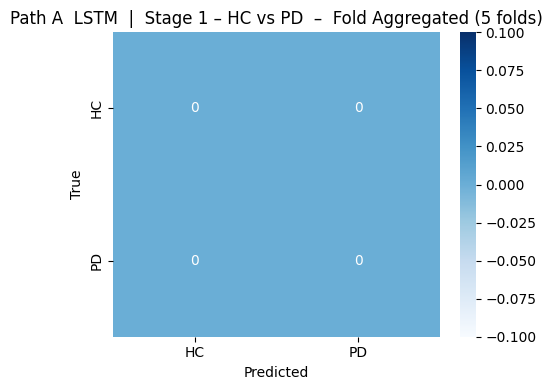

NameError: name 'plot_overfit_diagnostic' is not defined

In [ ]:
# ============================================================
# VISUALISATIONS  –  confusion matrices for all models/stages
# ============================================================

for stage_name, subj_df, label_map, class_names in stages_cfg:
    print(f"\n── {stage_name} ──────────────────────────────────")

    # Path A
    for model_name in dl_models:
        plot_confusion_matrix(
            path_a_cms[stage_name][model_name],
            f"Path A  {model_name}  |  {stage_name}",
            fold='Aggregated (5 folds)',
            class_names=class_names
        )
        plot_overfit_diagnostic(
            path_a_histories[stage_name][model_name],
            f"{model_name}  |  {stage_name}"
        )

    # Path B
    for model_name in ml_models:
        plot_confusion_matrix(
            path_b_cms[stage_name][model_name],
            f"Path B  {model_name}  |  {stage_name}",
            fold='Aggregated (5 folds)',
            class_names=class_names
        )


# ============================================================
# FINAL SUMMARY TABLE  –  all models, both stages
# ============================================================

print("\n" + "="*70)
print("  FINAL RESULTS SUMMARY")
print("="*70)

for stage_name, *_ in stages_cfg:
    print(f"\n  {stage_name}")
    print("  Path A (Deep Learning):")
    print(summarise_cv(path_a_results[stage_name]).to_string())
    print("\n  Path B (Machine Learning):")
    print(summarise_cv(path_b_results[stage_name]).to_string())

FOR CHECKING

In [ ]:
# ============================================================
# ADD THIS after training to diagnose overfitting visually
# ============================================================

def plot_overfit_diagnostic(histories: list, model_name: str):
    """
    Overlay all 5 folds' train vs val loss to spot overfitting.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors    = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']

    for fold_idx, (history, color) in enumerate(zip(histories, colors)):
        axes[0].plot(history['train_loss'], color=color,
                     linestyle='--', alpha=0.6, label=f'Train F{fold_idx+1}')
        axes[0].plot(history['val_loss'],   color=color,
                     linestyle='-',  alpha=0.9, label=f'Val F{fold_idx+1}')

        axes[1].plot(history['train_acc'], color=color,
                     linestyle='--', alpha=0.6)
        axes[1].plot(history['val_acc'],   color=color,
                     linestyle='-',  alpha=0.9)

    for ax, title in zip(axes, ['Loss', 'Accuracy']):
        ax.set_title(f'{model_name} – Train (--) vs Val (—) {title}')
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.3)

    axes[0].legend(fontsize=7, ncol=2)
    axes[0].set_ylabel('Loss')
    axes[1].set_ylabel('Accuracy')
    plt.tight_layout()
    plt.show()

# Call after training:
for model_name in dl_models:
    plot_overfit_diagnostic(path_a_histories[model_name], model_name)

KeyError: 'LSTM'

Min    : 6808
Max    : 49439
Mean   : 18108.2
Median : 16846.5
% sequences < 500 : 0.0%
% sequences < 250 : 0.0%


/tmp/ipykernel_3056/3775225448.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([task_lengths[t] for t in task_keys], labels=task_keys)


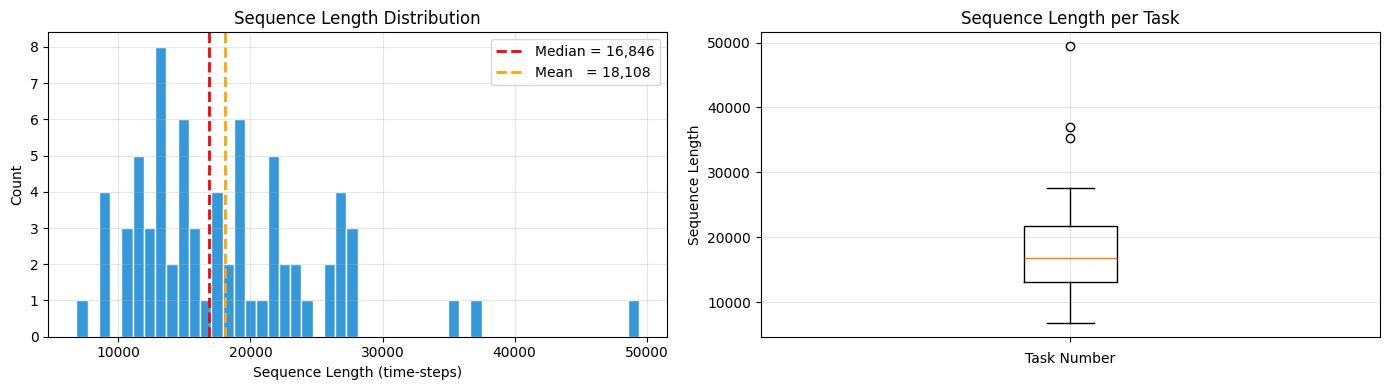

Percentile breakdown:
    5th percentile :   9,336 steps
   10th percentile :  10,550 steps
   25th percentile :  13,075 steps
   50th percentile :  16,846 steps
   75th percentile :  21,746 steps
   90th percentile :  26,796 steps
   95th percentile :  27,547 steps
  L= 1,000  →  array size ≈     1.1 MB
  L= 2,000  →  array size ≈     2.2 MB
  L= 5,000  →  array size ≈     5.5 MB
  L=10,000  →  array size ≈    11.0 MB
  L=16,846  →  array size ≈    18.5 MB


In [ ]:
# ============================================================
# FIX 1 – Check how many sequences are heavily zero-padded
# ============================================================
lengths = []
for (subj_id, task), grp in full_df.groupby(['subject_id', 'task']):
    lengths.append(len(grp))

lengths = np.array(lengths)
print(f"Min    : {lengths.min()}")
print(f"Max    : {lengths.max()}")
print(f"Mean   : {lengths.mean():.1f}")
print(f"Median : {np.median(lengths):.1f}")
print(f"% sequences < 500 : {(lengths < 500).mean()*100:.1f}%")
print(f"% sequences < 250 : {(lengths < 250).mean()*100:.1f}%")

# If most sequences are << 500, reduce L to median length
# e.g., if median is 200, set SEQUENCE_LENGTH = 200


# ============================================================
# STEP 1 – Visualise the distribution first
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

lengths = []
for (subj_id, task), grp in full_df.groupby(['subject_id', 'task']):
    lengths.append(len(grp))

lengths = np.array(lengths)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(lengths, bins=50, color='#3498db', edgecolor='white')
axes[0].axvline(np.median(lengths), color='red',    linestyle='--',
                linewidth=2, label=f'Median = {int(np.median(lengths)):,}')
axes[0].axvline(np.mean(lengths),   color='orange', linestyle='--',
                linewidth=2, label=f'Mean   = {int(np.mean(lengths)):,}')
axes[0].set_xlabel('Sequence Length (time-steps)')
axes[0].set_ylabel('Count')
axes[0].set_title('Sequence Length Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Per-task boxplot
task_lengths = {}
for (subj_id, task), grp in full_df.groupby(['subject_id', 'task']):
    task_lengths.setdefault(task, []).append(len(grp))

task_keys = sorted(task_lengths.keys())
axes[1].boxplot([task_lengths[t] for t in task_keys], labels=task_keys)
axes[1].set_xlabel('Task Number')
axes[1].set_ylabel('Sequence Length')
axes[1].set_title('Sequence Length per Task')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Percentile breakdown ──────────────────────────────────
print("Percentile breakdown:")
for p in [5, 10, 25, 50, 75, 90, 95]:
    print(f"  {p:>3}th percentile : {int(np.percentile(lengths, p)):>7,} steps")


# ── Check memory impact ───────────────────────────────────
for L in [1000, 2000, 5000, 10000, int(np.median(lengths))]:
    n_sequences = len(lengths)
    mem_mb = (n_sequences * L * 4 * 4) / (1024**2)  # float32, 4 features
    print(f"  L={L:>6,}  →  array size ≈ {mem_mb:>7.1f} MB")
